# Results, at full precision, with provenance

Every number and figure in one place, so that reading the results does not depend on
reconstructing which log entry a value came from.

**This is the audit surface, not a deliverable.** The registered 960-arm grid is closed.
Two targeted extensions (γ=5 at 40 unique arms/corner; width at γ=10, 40 unique arms/cell)
are in progress and must not be mixed with the files whose `stream_id` did not key the
arrangement. Nothing here is trained or measured. The job of the notebook is that every
number and figure in the paper can be checked against its data in one place, side by side,
so nothing rests on a claim whose support is not on the page.

Four properties it is built to have:

- **Nothing is trained or measured.** Every value is read from `results/` or `figures/` and
  derived. Attribution is re-derived from stored geometry, as everywhere else in this project;
  that is derivation, not measurement, and no cell here can produce a number that did not already
  exist on disk. Where a value cannot be re-derived, the table says so instead of hardcoding it.
- **Every table states its `n` and its arm-selection rule**, in the output rather than in a
  comment. `Table` refuses to render without them. Two of this project's errors were errors of
  *sourcing* — a right computation reading a wrong cell — and a 4-arm row that reached drafted
  text twice is why this is enforced rather than encouraged.
- **Every figure is paired with the table of values it was drawn from.** Same numbers, same n,
  same gates, same coverage. A figure whose numbers cannot be read off a table next to it is a
  figure that cannot be checked.
- **Full precision, with the paper's rounding beside it.** The number inventory compares at the
  precision the paper quotes; this is where the unrounded value lives.

The paper-number index (§11) is what the draft is read against. The unresolved-claims table
(§12) is every quantity the paper mentions that does not clear its gate, with the gate and the
margin. Caption cuts (§13) are proposed, not applied.

Run top to bottom. The last cell states the runtime. Grouping is three-corner unless a table
says otherwise; any section that still reports four-corner values is marked as such.

In [1]:
import sys, time
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.analysis import ledger as L

T0 = time.time()
L.show(f"Reading result set `{L.result_set_sha()}` at git `{L.git_sha()}`.")

Reading result set `8dd793134c38` at git `443945dc`.

In [2]:
L.header("1. Provenance and grid summary",
         ["results/phase1/*.json", "results/audit_scope.json"],
         note="Two git SHAs appear across the result set because the column-generation solver "
              "landed mid-grid. The scope audit re-derives every stored identity from current "
              "code and reports the worst disagreement, which is exactly zero, so the two halves "
              "of the grid are comparable rather than merely adjacent.")
L.grid_summary().display()

### 1. Provenance and grid summary

- **generating code**: `src/analysis/ledger.py` @ module hash `e6514ea6463a48a7`
- **git SHA**: `443945dc`
- **result set**: `8dd793134c38` (960 arms, a = 0 only)
- **reads**: `results/phase1/*.json`, `results/audit_scope.json`

Two git SHAs appear across the result set because the column-generation solver landed mid-grid. The scope audit re-derives every stored identity from current code and reports the worst disagreement, which is exactly zero, so the two halves of the grid are comparable rather than merely adjacent.


**Grid completeness and provenance**  
*n = 960; all a = 0 arms of the registered grid (γ ∈ {0.03…10}, N = 300)*  
*source: `results/phase1/*.json, results/audit_scope.json`*

| quantity | full precision | as quoted | n | note |
|---|---|---|---|---|
| arms on disk (all a) | 1280 | 1280 | 1280 |  |
| arms in the headline set (a = 0) | 960 | 960 | 960 | a > 0 arms have bitwise-identical modules; see 06-scope §4 |
| retained-capacity comparisons available | 9600 | — | 9600 | module A only, task-own-boundary baseline |
| worst identity residual | 4.437e-16 | 4.4 × 10⁻¹⁶ | 48,640 evaluations |  |
| git SHAs across the result set | 36399f28, 7544bb3a | — | 2 | two commits: the solver change mid-grid, both re-derived identically |
| scope-audit checks failing | 0 | 0 | 33 | of 33 checks; see `results/audit_scope.json` for each |
| arms non-converged | 0 | 0 | 1280 | every task in every arm reached the matched-loss target |


In [3]:
L.header("2. Noise floors",
         ["results/measurement_null.json", "src/analysis/timewarp.py"],
         note="A magnitude in this project is quoted in units of the estimator's own Monte-Carlo "
              "dispersion, which makes *unchanged* a measurement rather than a small number. The "
              "floors were measured directly: one trained representation per richness, "
              "re-measured under several measurement seeds, so the dispersion is the estimator's "
              "and not the training's.")
L.floors_table().display()
L.show(L.floor_denominated())

### 2. Noise floors

- **generating code**: `src/analysis/ledger.py` @ module hash `e6514ea6463a48a7`
- **git SHA**: `443945dc`
- **result set**: `8dd793134c38` (960 arms, a = 0 only)
- **reads**: `results/measurement_null.json`, `src/analysis/timewarp.py`

A magnitude in this project is quoted in units of the estimator's own Monte-Carlo dispersion, which makes *unchanged* a measurement rather than a small number. The floors were measured directly: one trained representation per richness, re-measured under several measurement seeds, so the dispersion is the estimator's and not the training's.


**Measurement floors: registered, and re-measured per richness**  
*n = 4 seeds per γ; one trained representation per γ, re-measured under several measurement seeds; modules A and B pooled in quadrature*  
*source: `results/measurement_null.json, src/analysis/timewarp.py`*

| quantity | full precision | as quoted | n | note |
|---|---|---|---|---|
| registered D_eff floor (CV) | 0.0126 | — | — | used for cross-γ comparisons |
| registered R_eff floor (CV) | 0.005 | — | — | **superseded** by the per-γ values below; kept because cross-γ comparisons of other channels still use the registered registry |
| registered alpha floor (CV) | 0.0187 | — | — | used for cross-γ comparisons |
| registered rho_c_glue floor (CV) | 0.0097 | — | — | used for cross-γ comparisons |
| measured R_eff floor at γ = 0.03 (CV) | 0.00280325 | 0.28%–1.13% across γ | 4 | rises monotonically with richness — not a constant |
| measured R_eff floor at γ = 0.1 (CV) | 0.00306809 | 0.28%–1.13% across γ | 4 | rises monotonically with richness — not a constant |
| measured R_eff floor at γ = 0.3 (CV) | 0.00618483 | 0.28%–1.13% across γ | 4 | rises monotonically with richness — not a constant |
| measured R_eff floor at γ = 1 (CV) | 0.00807549 | 0.28%–1.13% across γ | 4 | rises monotonically with richness — not a constant |
| measured R_eff floor at γ = 3 (CV) | 0.0071546 | 0.28%–1.13% across γ | 4 | rises monotonically with richness — not a constant |
| measured R_eff floor at γ = 10 (CV) | 0.0112487 | 0.28%–1.13% across γ | 4 | rises monotonically with richness — not a constant |
| α floor, measured range across γ (CV) | 0.0157–0.0236 | 1.49%–2.03% | 4 | flat in γ; registered 1.87% stands |
| panel (d) gate | 3 | 3× | — | 3 floors, not 1: a denominator at 1σ carries ~100% relative error |
| resolution limit of this design | ×/÷ 2.2 | ~2× | 4 | a CV estimated from 4 seeds has relative standard error 1/√(2(n−1)) = 0.41, so the floors themselves are only good to about a factor of two — which is why a 2.3× error in one of them was detectable and a 20% one would not have been |


Quantities denominated in a measured floor: the capacity magnitudes of §5.1 and §5.3 (α floor), the geometric excursion progression (per channel), and panel (d)'s gate (`R_eff` floor, per γ, at 3σ). Quantities **not** floor-denominated, and therefore read against their own bootstrap or sign test instead: Δρ_c and its 2×2 decomposition, the probe correlations, and every R² in §B.

### 3. Figure 2 — the decomposition, at both groupings

- **generating code**: `src/analysis/ledger.py` @ module hash `e6514ea6463a48a7`
- **git SHA**: `443945dc`
- **result set**: `8dd793134c38` (960 arms, a = 0 only)
- **reads**: `results/phase1/*.json`, `results/measurement_null.json`, `figures/fig2_gamma_sweep__forgetting__lag12__*.json`

The plotted-values table sits on the PNG. Both groupings are then shown side by side because the paper's number changed when the grouping did, and a reader meeting a 37% movement deserves to see that it is a change of population rather than a correction. The four-corner table is marked **superseded**; it is not wrong about the four corners, it is wrong as a description of forgetting, because one of the four gains capacity.


**`fig2` — plotted values, then the rendering. Same numbers, same n, same gates.**

> **Grouping: three-corner (the paper's forgetting pool: S-HL, S-LH, S-LL)**

**Figure 2 — plotted values (one row per richness bar)**  
*n = 120; lag 12, task 0, three forgetting corners; n is comparisons per γ, matching the figure sidecar*  
*source: `figures/fig2_gamma_sweep__forgetting__lag12__*.json`*

| quantity | full precision | as quoted | n | note |
|---|---|---|---|---|
| γ = 0.03: Δ log α | -0.00325363 | 0.2 floors | 120 | -0.1756 floors; utility 0.0761634, radius 0.366335, dimension 0.557501 — **below the ±2-floor band, shares not drawn**; center-collapse share n/a, coverage 0%, gate 0.0084 log units (3 × R_eff floor at this γ) |
| γ = 0.1: Δ log α | -0.0389438 | 2.1 floors | 120 | -2.102 floors; utility 0.0833736, radius 0.38693, dimension 0.529697; center-collapse share 0.053467704522182476, coverage 58%, gate 0.0092 log units (3 × R_eff floor at this γ) |
| γ = 0.3: Δ log α | -0.185948 | — | 120 | -10.04 floors; utility 0.189269, radius 0.367544, dimension 0.443186; center-collapse share 0.12211998058323455, coverage 92%, gate 0.0185 log units (3 × R_eff floor at this γ) |
| γ = 1: Δ log α | -0.484886 | — | 120 | -26.17 floors; utility 0.332395, radius 0.246406, dimension 0.421199; center-collapse share 0.25640617456667036, coverage 100%, gate 0.0241 log units (3 × R_eff floor at this γ) |
| γ = 3: Δ log α | -0.839974 | — | 120 | -45.34 floors; utility 0.414176, radius 0.149951, dimension 0.435873; center-collapse share 0.44168591876535146, coverage 100%, gate 0.0214 log units (3 × R_eff floor at this γ) |
| γ = 10: Δ log α | -1.29168 | 69.7 floors | 120 | -69.72 floors; utility 0.449186, radius 0.114048, dimension 0.436766; center-collapse share 0.44955037657960645, coverage 100%, gate 0.0336 log units (3 × R_eff floor at this γ) |
| utility share at first resolvable γ | 0.0833736 | 0.08 | 120 | panel (b) left endpoint |
| utility share at γ = 10 | 0.449186 | 0.45 | 120 | panel (b) right endpoint |
| radius share at first resolvable γ | 0.38693 | 0.39 | 120 |  |
| radius share at γ = 10 | 0.114048 | 0.11 | 120 |  |
| dimension share at first resolvable γ | 0.529697 | 0.53 | 120 |  |
| dimension share at γ = 10 | 0.436766 | 0.44 | 120 | flat after the first resolvable step |
| center-collapse share at γ = 3 | 0.441686 | 0.44 | 120 | the through-γ=3 rise the caption quotes |
| center-collapse share at γ = 10 | 0.44955 | 0.45 | 120 | the γ=3→10 step is in unresolved_claims_table() |
| panel (d) coverage at γ = 0.03 | 0 | 0% | 120 | **empty bar** — nothing clears the 3σ gate |
| utility sign-positive fraction, γ ≥ 1 | 0 | 0% / 100% negative | 120 | panel (c) |


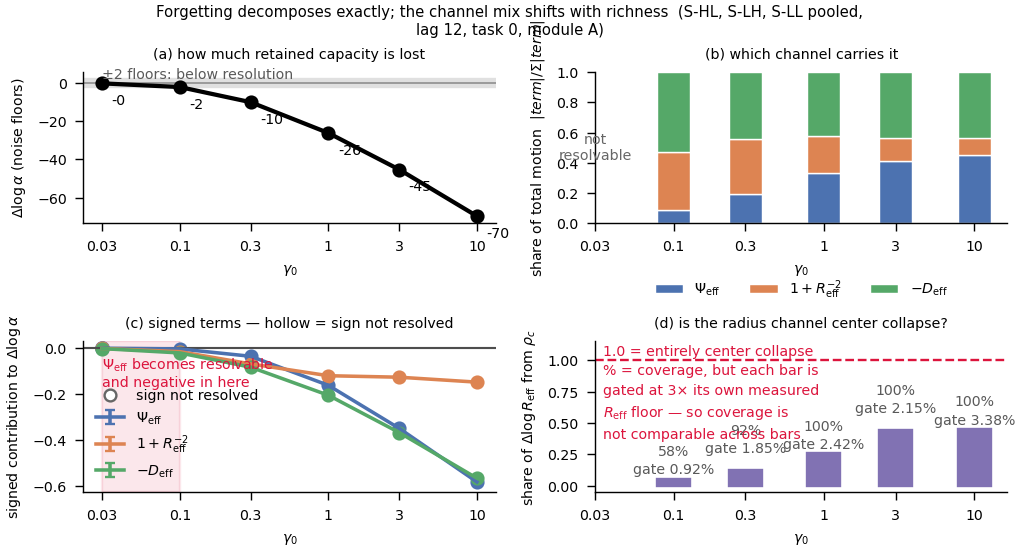

> **Grouping: three-corner (the paper's forgetting pool: S-HL, S-LH, S-LL)**

**Figure 2 — magnitude and decomposition, three forgetting corners (the paper's grouping)**  
*n = 120 comparisons per γ; lag 12, which exists only for task 0; module A; conditions ['S-HL', 'S-LH', 'S-LL']*  
*source: `results/phase1/*.json (attribution re-derived)`*

| quantity | full precision | as quoted | n | note |
|---|---|---|---|---|
| γ = 0.03: Δ log α | -0.00325363 | — | 120 | -0.2 floors — **below floor** |
| γ = 0.03: utility term (signed) | -0.000247807 | — | 120 | share 0.076 |
| γ = 0.03: radius term (signed) | -0.00119192 | — | 120 | share 0.366 |
| γ = 0.03: dimension term (signed) | -0.0018139 | — | 120 | share 0.558 |
| γ = 0.1: Δ log α | -0.0389438 | — | 120 | -2.1 floors — resolvable |
| γ = 0.1: utility term (signed) | -0.00324688 | — | 120 | share 0.083 |
| γ = 0.1: radius term (signed) | -0.0150685 | — | 120 | share 0.387 |
| γ = 0.1: dimension term (signed) | -0.0206284 | — | 120 | share 0.530 |
| γ = 0.3: Δ log α | -0.185948 | — | 120 | -10.0 floors — resolvable |
| γ = 0.3: utility term (signed) | -0.0351943 | — | 120 | share 0.189 |
| γ = 0.3: radius term (signed) | -0.0683443 | — | 120 | share 0.368 |
| γ = 0.3: dimension term (signed) | -0.0824098 | — | 120 | share 0.443 |
| γ = 1: Δ log α | -0.484886 | — | 120 | -26.2 floors — resolvable |
| γ = 1: utility term (signed) | -0.161174 | — | 120 | share 0.332 |
| γ = 1: radius term (signed) | -0.119479 | — | 120 | share 0.246 |
| γ = 1: dimension term (signed) | -0.204233 | — | 120 | share 0.421 |
| γ = 3: Δ log α | -0.839974 | — | 120 | -45.3 floors — resolvable |
| γ = 3: utility term (signed) | -0.347897 | — | 120 | share 0.414 |
| γ = 3: radius term (signed) | -0.125955 | — | 120 | share 0.150 |
| γ = 3: dimension term (signed) | -0.366122 | — | 120 | share 0.436 |
| γ = 10: Δ log α | -1.29168 | — | 120 | -69.7 floors — resolvable |
| γ = 10: utility term (signed) | -0.580203 | — | 120 | share 0.449 |
| γ = 10: radius term (signed) | -0.147313 | — | 120 | share 0.114 |
| γ = 10: dimension term (signed) | -0.564162 | — | 120 | share 0.437 |


> **Grouping: four-corner (superseded by the regroup; shown so the movement is visible, not so it can be quoted as forgetting)**

**Figure 2 — magnitude and decomposition, all four corners (superseded: mixes a gain with three losses)**  
*n = 160 comparisons per γ; lag 12, which exists only for task 0; module A; conditions ['S-HH', 'S-HL', 'S-LH', 'S-LL']*  
*source: `results/phase1/*.json (attribution re-derived)`*

| quantity | full precision | as quoted | n | note |
|---|---|---|---|---|
| γ = 0.03: Δ log α | 0.00117746 | — | 160 | +0.1 floors — **below floor** |
| γ = 0.03: utility term (signed) | 0.000506099 | — | 160 | share 0.430 |
| γ = 0.03: radius term (signed) | 0.000580454 | — | 160 | share 0.493 |
| γ = 0.03: dimension term (signed) | 9.09104e-05 | — | 160 | share 0.077 |
| γ = 0.1: Δ log α | -0.00830955 | — | 160 | -0.4 floors — **below floor** |
| γ = 0.1: utility term (signed) | 0.0021972 | — | 160 | share 0.173 |
| γ = 0.1: radius term (signed) | -0.0029381 | — | 160 | share 0.231 |
| γ = 0.1: dimension term (signed) | -0.00756865 | — | 160 | share 0.596 |
| γ = 0.3: Δ log α | -0.0961866 | — | 160 | -5.2 floors — resolvable |
| γ = 0.3: utility term (signed) | -0.00972468 | — | 160 | share 0.101 |
| γ = 0.3: radius term (signed) | -0.0405046 | — | 160 | share 0.421 |
| γ = 0.3: dimension term (signed) | -0.0459573 | — | 160 | share 0.478 |
| γ = 1: Δ log α | -0.308813 | — | 160 | -16.7 floors — resolvable |
| γ = 1: utility term (signed) | -0.0878086 | — | 160 | share 0.284 |
| γ = 1: radius term (signed) | -0.0934665 | — | 160 | share 0.303 |
| γ = 1: dimension term (signed) | -0.127538 | — | 160 | share 0.413 |
| γ = 3: Δ log α | -0.579642 | — | 160 | -31.3 floors — resolvable |
| γ = 3: utility term (signed) | -0.235639 | — | 160 | share 0.407 |
| γ = 3: radius term (signed) | -0.0948491 | — | 160 | share 0.164 |
| γ = 3: dimension term (signed) | -0.249154 | — | 160 | share 0.430 |
| γ = 10: Δ log α | -0.940227 | — | 160 | -50.7 floors — resolvable |
| γ = 10: utility term (signed) | -0.421329 | — | 160 | share 0.448 |
| γ = 10: radius term (signed) | -0.113576 | — | 160 | share 0.121 |
| γ = 10: dimension term (signed) | -0.405321 | — | 160 | share 0.431 |


> **Grouping: three-corner (the paper's forgetting pool: S-HL, S-LH, S-LL)**

**Panel (d) — center-collapse share, with each bar's own gate**  
*n = 120 comparisons per γ; lag 12, task 0, three forgetting corners; a cell is reported only if |Δ log R_eff| clears 3× the R_eff floor measured at that γ*  
*source: `results/phase1/*.json, results/measurement_null.json`*

| quantity | full precision | as quoted | n | note |
|---|---|---|---|---|
| γ = 0.03: median share | *not re-derivable from stored data* | — | 0/120 | coverage 0%, gate 0.0084 log units — coverage is **not** comparable across rows |
| γ = 0.1: median share | 0.0534677 | — | 70/120 | coverage 58%, gate 0.0092 log units — coverage is **not** comparable across rows |
| γ = 0.3: median share | 0.12212 | — | 110/120 | coverage 92%, gate 0.0185 log units — coverage is **not** comparable across rows |
| γ = 1: median share | 0.256406 | — | 120/120 | coverage 100%, gate 0.0241 log units — coverage is **not** comparable across rows |
| γ = 3: median share | 0.441686 | — | 120/120 | coverage 100%, gate 0.0214 log units — coverage is **not** comparable across rows |
| γ = 10: median share | 0.44955 | — | 120/120 | coverage 100%, gate 0.0336 log units — coverage is **not** comparable across rows |


In [4]:
L.header("3. Figure 2 — the decomposition, at both groupings",
         ["results/phase1/*.json", "results/measurement_null.json",
          "figures/fig2_gamma_sweep__forgetting__lag12__*.json"],
         note="The plotted-values table sits on the PNG. Both groupings are then shown side by "
              "side because the paper's number changed when the grouping did, and a reader "
              "meeting a 37% movement deserves to see that it is a change of population rather "
              "than a correction. The four-corner table is marked **superseded**; it is not "
              "wrong about the four corners, it is wrong as a description of forgetting, because "
              "one of the four gains capacity.")
L.show_figure_with_table("fig2")
for t in L.figure2_tables():
    t.display()
L.panel_d_table().display()

### 4. Backward transfer in the benign corner

- **generating code**: `src/analysis/ledger.py` @ module hash `e6514ea6463a48a7`
- **git SHA**: `443945dc`
- **result set**: `8dd793134c38` (960 arms, a = 0 only)
- **reads**: `results/phase1/*.json`, `results/audit_propagation.json`, `results/tier2_backward_transfer.json`, `figures/fig2_gamma_sweep__S-HH__lag12__*.json`

**2.1** The gain and the losses do not differ in all three *resolved* channels. Utility and dimension carry the gain; they carry the losses with the opposite sign. The radius term is negative in every resolvable corner for γ ≥ 1 **as a signed term**, but that is not a shared-channel claim: in S-HH it does not clear the analysis's own 3σ R_eff gate (1.9, 0.2, 1.1 floors at γ = 1, 3, 10). The paper claims no sign for it, only a bound. The gate table is immediately below the figure, so the unresolved status is visible rather than asserted. Shares are **signed**: `|term|/Σ|term|` would show the opposing radius term as an 11% contribution to a gain it subtracts from.

**2.2** General. All ten (task, lag) cells resolve as gains at each of γ = 1, 3 and 10. The framing for each possible outcome was fixed in `results/LOG.md` before the run, because a gain confined to task 0 would have been a claim about the first task's position rather than about backward transfer. It is not confined: at matched lag the *earliest* task gains least.

**2.3** Not located, and the reason is not the one anticipated. At lag 12 the peak is sharply determined — γ = 1.23, paired-bootstrap CI [1.18, 1.28]. But it moves monotonically with lag, from 2.86 at lag 4 to 0.96 at lag 15, so there is one peak per lag rather than one for the corner and the question is ill-posed without fixing the lag. **The text rule was unconditional and still is**: no sentence in the paper contains both this peak and the behavioural optimum. Note that the original justification — that both locations are unresolved — turned out to be wrong in an instructive way. At any fixed lag the peak is *very* well resolved. What is unresolved is the behavioural optimum, and a peak that sweeps the whole of its interval as lag varies cannot agree with it.


**`fig2_benign` — plotted values, then the rendering. Same numbers, same n, same gates.**

> **Grouping: S-HH alone (not a pool)**

**Figure S (benign) — plotted values (one row per richness bar)**  
*n = 40; lag 12, task 0, S-HH alone*  
*source: `figures/fig2_gamma_sweep__S-HH__lag12__*.json`*

| quantity | full precision | as quoted | n | note |
|---|---|---|---|---|
| γ = 0.03: Δ log α | 0.0144707 | — | 40 | +0.781 floors; utility 0.19127, radius 0.407552, dimension 0.401179 — **below the ±2-floor band, shares not drawn**; center-collapse share n/a, coverage 0%, gate 0.0084 log units (3 × R_eff floor at this γ) |
| γ = 0.1: Δ log α | 0.0835931 | — | 40 | +4.512 floors; utility 0.221662, radius 0.40019, dimension 0.378148; center-collapse share 0.017755033204028166, coverage 100%, gate 0.0092 log units (3 × R_eff floor at this γ) |
| γ = 0.3: Δ log α | 0.173099 | — | 40 | +9.343 floors; utility 0.385238, radius 0.248496, dimension 0.366265; center-collapse share 0.15230807988199407, coverage 100%, gate 0.0185 log units (3 × R_eff floor at this γ) |
| γ = 1: Δ log α | 0.219407 | 11.8 floors | 40 | +11.84 floors; utility 0.528584, radius 0.0616551, dimension 0.409761; center-collapse share -0.5023282621626397, coverage 12%, gate 0.0241 log units (3 × R_eff floor at this γ) |
| γ = 3: Δ log α | 0.201354 | — | 40 | +10.87 floors; utility 0.494746, radius 0.00749513, dimension 0.497759; center-collapse share n/a, coverage 0%, gate 0.0214 log units (3 × R_eff floor at this γ) |
| γ = 10: Δ log α | 0.114127 | 6.2 floors | 40 | +6.16 floors; utility 0.398195, radius 0.0890487, dimension 0.512756; center-collapse share n/a, coverage 0%, gate 0.0336 log units (3 × R_eff floor at this γ) |


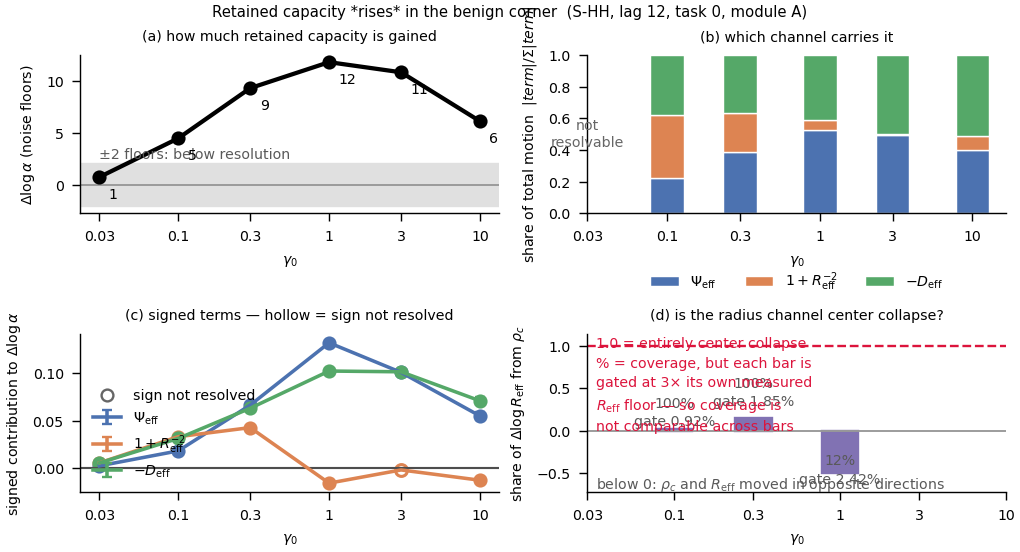

> **Grouping: S-HH alone (not a pool)**

**S-HH radius term vs the analysis's own 3σ R_eff gate**  
*n = 40; lag 12, task 0, S-HH alone; gate = 3 × log(1 + R_eff CV) at that γ, the same threshold panel (d) uses as a denominator. The two-floor convention on α is a different ruler and is shown beside it.*  
*source: `figures/fig2_gamma_sweep__S-HH__lag12__*.json, src/analysis/attribution.py`*

| quantity | full precision | as quoted | n | note |
|---|---|---|---|---|
| γ = 0.03: radius term | 0.00589757 | — | 40 | gate 0.0084 log units; 2.11 R_eff floors; **does not clear** the 3σ gate; two-floor convention would pass |
| γ = 0.1: radius term | 0.0334531 | — | 40 | gate 0.0092 log units; 10.91 R_eff floors; **clears** the 3σ gate |
| γ = 0.3: radius term | 0.0430144 | — | 40 | gate 0.0185 log units; 6.98 R_eff floors; **clears** the 3σ gate |
| γ = 1: radius term | -0.0154302 | 1.9 floors | 40 | gate 0.0241 log units; 1.92 R_eff floors; **does not clear** the 3σ gate; also below the two-floor convention; this is the unresolved series the paper quotes as a bound |
| γ = 3: radius term | -0.00153214 | 0.2 floors | 40 | gate 0.0214 log units; 0.22 R_eff floors; **does not clear** the 3σ gate; also below the two-floor convention; this is the unresolved series the paper quotes as a bound |
| γ = 10: radius term | -0.012365 | 1.1 floors | 40 | gate 0.0336 log units; 1.11 R_eff floors; **does not clear** the 3σ gate; also below the two-floor convention; this is the unresolved series the paper quotes as a bound |


> **Grouping: S-HH alone (not a pool)**

**S-HH backward transfer — magnitude and channel signature**  
*n = 40 comparisons per γ; lag 12 (task 0), module A, the benign corner alone; the loss corners are shown beside it at matched γ*  
*source: `results/phase1/*.json (attribution re-derived)`*

| quantity | full precision | as quoted | n | note |
|---|---|---|---|---|
| γ = 0.03: Δ log α | 0.0144707 | — | 40 | +0.8 floors against -0.2 for the loss corners; uti +0.0028 rad +0.0059 dim +0.0058; all three terms agree in sign |
| γ = 0.1: Δ log α | 0.0835931 | — | 40 | +4.5 floors against -2.1 for the loss corners; uti +0.0185 rad +0.0335 dim +0.0316; all three terms agree in sign |
| γ = 0.3: Δ log α | 0.173099 | — | 40 | +9.3 floors against -10.0 for the loss corners; uti +0.0667 rad +0.0430 dim +0.0634; all three terms agree in sign |
| γ = 1: Δ log α | 0.219407 | — | 40 | +11.8 floors against -26.2 for the loss corners; uti +0.1323 rad -0.0154 dim +0.1025; **radius opposes** the other two |
| γ = 3: Δ log α | 0.201354 | — | 40 | +10.9 floors against -45.3 for the loss corners; uti +0.1011 rad -0.0015 dim +0.1018; **radius opposes** the other two |
| γ = 10: Δ log α | 0.114127 | — | 40 | +6.2 floors against -69.7 for the loss corners; uti +0.0553 rad -0.0124 dim +0.0712; **radius opposes** the other two |


> **Grouping: four-corner by design — a 2×2 / per-corner split, not the forgetting pool**

**2.1 — the gain and the losses in the same three-term currency**  
*n = 40; lag 12 (task 0), module A, each corner separately; only richnesses where the corner clears ±2 floors are shown, since a term of an unresolvable total is not interpretable. Signed-term agreement is not a gate — S-HH radius vs the analysis's own 3σ R_eff gate is radius_vs_gate_table(), and at γ ≥ 1 it does not clear.*  
*source: `results/tier2_backward_transfer.json (scripts/tier2_backward_transfer.py)`*

| quantity | full precision | as quoted | n | note |
|---|---|---|---|---|
| γ = 0.1: S-HH | 0.0835931 | — | 40 | +4.5 floors; signed shares of the net — uti +0.222 rad +0.400 dim +0.378 |
| γ = 0.1: radius term negative in every resolvable corner | False | — | — | signed-term agreement is **not** a shared-channel claim. At γ ≥ 1 S-HH's radius term is negative but below the 3σ R_eff gate — see radius_vs_gate_table(). The paper claims a bound, not a sign. |
| γ = 0.1: S-HL | -0.0727541 | — | 40 | -3.9 floors; signed shares of the net — uti +0.117 rad +0.397 dim +0.486 |
| γ = 0.1: radius term negative in every resolvable corner | False | — | — | signed-term agreement is **not** a shared-channel claim. At γ ≥ 1 S-HH's radius term is negative but below the 3σ R_eff gate — see radius_vs_gate_table(). The paper claims a bound, not a sign. |
| γ = 0.1: S-LL | -0.0461109 | — | 40 | -2.5 floors; signed shares of the net — uti +0.141 rad +0.361 dim +0.498 |
| γ = 0.1: radius term negative in every resolvable corner | False | — | — | signed-term agreement is **not** a shared-channel claim. At γ ≥ 1 S-HH's radius term is negative but below the 3σ R_eff gate — see radius_vs_gate_table(). The paper claims a bound, not a sign. |
| γ = 0.3: S-HH | 0.173099 | — | 40 | +9.3 floors; signed shares of the net — uti +0.385 rad +0.248 dim +0.366 |
| γ = 0.3: radius term negative in every resolvable corner | False | — | — | signed-term agreement is **not** a shared-channel claim. At γ ≥ 1 S-HH's radius term is negative but below the 3σ R_eff gate — see radius_vs_gate_table(). The paper claims a bound, not a sign. |
| γ = 0.3: S-HL | -0.283028 | — | 40 | -15.3 floors; signed shares of the net — uti +0.203 rad +0.365 dim +0.432 |
| γ = 0.3: radius term negative in every resolvable corner | False | — | — | signed-term agreement is **not** a shared-channel claim. At γ ≥ 1 S-HH's radius term is negative but below the 3σ R_eff gate — see radius_vs_gate_table(). The paper claims a bound, not a sign. |
| γ = 0.3: S-LH | -0.0709589 | — | 40 | -3.8 floors; signed shares of the net — uti +0.068 rad +0.430 dim +0.502 |
| γ = 0.3: radius term negative in every resolvable corner | False | — | — | signed-term agreement is **not** a shared-channel claim. At γ ≥ 1 S-HH's radius term is negative but below the 3σ R_eff gate — see radius_vs_gate_table(). The paper claims a bound, not a sign. |
| γ = 0.3: S-LL | -0.203858 | — | 40 | -11.0 floors; signed shares of the net — uti +0.212 rad +0.350 dim +0.438 |
| γ = 0.3: radius term negative in every resolvable corner | False | — | — | signed-term agreement is **not** a shared-channel claim. At γ ≥ 1 S-HH's radius term is negative but below the 3σ R_eff gate — see radius_vs_gate_table(). The paper claims a bound, not a sign. |
| γ = 1: S-HH | 0.219407 | — | 40 | +11.8 floors; signed shares of the net — uti +0.603 rad -0.070 dim +0.467 |
| γ = 1: radius term negative in every resolvable corner | True | — | — | signed-term agreement is **not** a shared-channel claim. At γ ≥ 1 S-HH's radius term is negative but below the 3σ R_eff gate — see radius_vs_gate_table(). The paper claims a bound, not a sign. |
| γ = 1: S-HL | -0.691864 | — | 40 | -37.3 floors; signed shares of the net — uti +0.330 rad +0.251 dim +0.419 |
| γ = 1: radius term negative in every resolvable corner | True | — | — | signed-term agreement is **not** a shared-channel claim. At γ ≥ 1 S-HH's radius term is negative but below the 3σ R_eff gate — see radius_vs_gate_table(). The paper claims a bound, not a sign. |
| γ = 1: S-LH | -0.258584 | — | 40 | -14.0 floors; signed shares of the net — uti +0.296 rad +0.282 dim +0.422 |
| γ = 1: radius term negative in every resolvable corner | True | — | — | signed-term agreement is **not** a shared-channel claim. At γ ≥ 1 S-HH's radius term is negative but below the 3σ R_eff gate — see radius_vs_gate_table(). The paper claims a bound, not a sign. |
| γ = 1: S-LL | -0.504209 | — | 40 | -27.2 floors; signed shares of the net — uti +0.355 rad +0.222 dim +0.423 |
| γ = 1: radius term negative in every resolvable corner | True | — | — | signed-term agreement is **not** a shared-channel claim. At γ ≥ 1 S-HH's radius term is negative but below the 3σ R_eff gate — see radius_vs_gate_table(). The paper claims a bound, not a sign. |
| γ = 3: S-HH | 0.201354 | — | 40 | +10.9 floors; signed shares of the net — uti +0.502 rad -0.008 dim +0.505 |
| γ = 3: radius term negative in every resolvable corner | True | — | — | signed-term agreement is **not** a shared-channel claim. At γ ≥ 1 S-HH's radius term is negative but below the 3σ R_eff gate — see radius_vs_gate_table(). The paper claims a bound, not a sign. |
| γ = 3: S-HL | -1.11669 | — | 40 | -60.3 floors; signed shares of the net — uti +0.413 rad +0.156 dim +0.431 |
| γ = 3: radius term negative in every resolvable corner | True | — | — | signed-term agreement is **not** a shared-channel claim. At γ ≥ 1 S-HH's radius term is negative but below the 3σ R_eff gate — see radius_vs_gate_table(). The paper claims a bound, not a sign. |
| γ = 3: S-LH | -0.551524 | — | 40 | -29.8 floors; signed shares of the net — uti +0.383 rad +0.169 dim +0.448 |
| γ = 3: radius term negative in every resolvable corner | True | — | — | signed-term agreement is **not** a shared-channel claim. At γ ≥ 1 S-HH's radius term is negative but below the 3σ R_eff gate — see radius_vs_gate_table(). The paper claims a bound, not a sign. |
| γ = 3: S-LL | -0.851703 | — | 40 | -46.0 floors; signed shares of the net — uti +0.436 rad +0.130 dim +0.434 |
| γ = 3: radius term negative in every resolvable corner | True | — | — | signed-term agreement is **not** a shared-channel claim. At γ ≥ 1 S-HH's radius term is negative but below the 3σ R_eff gate — see radius_vs_gate_table(). The paper claims a bound, not a sign. |
| γ = 10: S-HH | 0.114127 | — | 40 | +6.2 floors; signed shares of the net — uti +0.484 rad -0.108 dim +0.624 |
| γ = 10: radius term negative in every resolvable corner | True | — | — | signed-term agreement is **not** a shared-channel claim. At γ ≥ 1 S-HH's radius term is negative but below the 3σ R_eff gate — see radius_vs_gate_table(). The paper claims a bound, not a sign. |
| γ = 10: S-HL | -1.53986 | — | 40 | -83.1 floors; signed shares of the net — uti +0.469 rad +0.100 dim +0.431 |
| γ = 10: radius term negative in every resolvable corner | True | — | — | signed-term agreement is **not** a shared-channel claim. At γ ≥ 1 S-HH's radius term is negative but below the 3σ R_eff gate — see radius_vs_gate_table(). The paper claims a bound, not a sign. |
| γ = 10: S-LH | -1.03472 | — | 40 | -55.8 floors; signed shares of the net — uti +0.397 rad +0.152 dim +0.451 |
| γ = 10: radius term negative in every resolvable corner | True | — | — | signed-term agreement is **not** a shared-channel claim. At γ ≥ 1 S-HH's radius term is negative but below the 3σ R_eff gate — see radius_vs_gate_table(). The paper claims a bound, not a sign. |
| γ = 10: S-LL | -1.30045 | — | 40 | -70.2 floors; signed shares of the net — uti +0.466 rad +0.100 dim +0.433 |
| γ = 10: radius term negative in every resolvable corner | True | — | — | signed-term agreement is **not** a shared-channel claim. At γ ≥ 1 S-HH's radius term is negative but below the 3σ R_eff gate — see radius_vs_gate_table(). The paper claims a bound, not a sign. |


> **Grouping: four-corner by design — a 2×2 / per-corner split, not the forgetting pool**

**Is the gain unique to that corner?**  
*n = 520; every (γ, condition, N, task, lag) cell of the registered grid, the width arms and the γ = 30 probe; a cell counts as a gain if its mean Δ log α is positive*  
*source: `results/audit_propagation.json (scripts/audit_propagation.py)`*

| quantity | full precision | as quoted | n | note |
|---|---|---|---|---|
| cells examined | 520 | 520 | 520 |  |
| cells with a positive mean | 172 | — | 520 |  |
| of those, clearing ±2 floors | 98 | 98 | 520 |  |
| resolvable gains outside S-HH | 0 | 0 | 520 | so backward transfer is a property of that corner, not a tendency present elsewhere in weaker form |
| largest positive cell outside S-HH | 0.73898 | 0.74 floors | — | a third of the resolution gate |


> **Grouping: S-HH alone (not a pool)**

**2.2 — is the gain general, or a property of task 0 at lag 12?**  
*n = 40; the benign corner only; position read at matched lag 4 (tasks 0, 4, 8) and lag read within task 0 (lags 4, 8, 12, 15). Lag and position are confounded by construction, so the two series are never pooled*  
*source: `results/tier2_backward_transfer.json (scripts/tier2_backward_transfer.py)`*

| quantity | full precision | as quoted | n | note |
|---|---|---|---|---|
| γ = 1: verdict | general | general | 400 | 3/3 positions, 4/4 lags, 10/10 cells resolve as gains |
| γ = 1: task 0 (at lag 4) | 0.167996 | — | 40 | +9.1 floors, CI [+8.8, +9.3] |
| γ = 1: task 4 (at lag 4) | 0.192296 | — | 40 | +10.4 floors, CI [+10.0, +10.8] |
| γ = 1: task 8 (at lag 4) | 0.188089 | — | 40 | +10.2 floors, CI [+9.7, +10.6] |
| γ = 1: lag 4 (within task 0) | 0.167996 | — | 40 | +9.1 floors, CI [+8.8, +9.3] |
| γ = 1: lag 8 (within task 0) | 0.219628 | — | 40 | +11.9 floors, CI [+11.6, +12.1] |
| γ = 1: lag 12 (within task 0) | 0.219407 | — | 40 | +11.8 floors, CI [+11.5, +12.1] |
| γ = 1: lag 15 (within task 0) | 0.208072 | — | 40 | +11.2 floors, CI [+10.8, +11.6] |
| γ = 3: verdict | general | general | 400 | 3/3 positions, 4/4 lags, 10/10 cells resolve as gains |
| γ = 3: task 0 (at lag 4) | 0.181854 | — | 40 | +9.8 floors, CI [+9.6, +10.0] |
| γ = 3: task 4 (at lag 4) | 0.237534 | — | 40 | +12.8 floors, CI [+12.2, +13.3] |
| γ = 3: task 8 (at lag 4) | 0.237982 | — | 40 | +12.8 floors, CI [+12.3, +13.4] |
| γ = 3: lag 4 (within task 0) | 0.181854 | — | 40 | +9.8 floors, CI [+9.6, +10.0] |
| γ = 3: lag 8 (within task 0) | 0.22008 | — | 40 | +11.9 floors, CI [+11.6, +12.1] |
| γ = 3: lag 12 (within task 0) | 0.201354 | — | 40 | +10.9 floors, CI [+10.5, +11.2] |
| γ = 3: lag 15 (within task 0) | 0.173824 | — | 40 | +9.4 floors, CI [+8.9, +9.9] |
| γ = 10: verdict | general | general | 400 | 3/3 positions, 4/4 lags, 10/10 cells resolve as gains |
| γ = 10: task 0 (at lag 4) | 0.162101 | — | 40 | +8.7 floors, CI [+8.5, +9.0] |
| γ = 10: task 4 (at lag 4) | 0.232706 | — | 40 | +12.6 floors, CI [+11.9, +13.2] |
| γ = 10: task 8 (at lag 4) | 0.236299 | — | 40 | +12.8 floors, CI [+12.0, +13.5] |
| γ = 10: lag 4 (within task 0) | 0.162101 | — | 40 | +8.7 floors, CI [+8.5, +9.0] |
| γ = 10: lag 8 (within task 0) | 0.16637 | — | 40 | +9.0 floors, CI [+8.6, +9.4] |
| γ = 10: lag 12 (within task 0) | 0.114127 | — | 40 | +6.2 floors, CI [+5.5, +6.8] |
| γ = 10: lag 15 (within task 0) | 0.0579084 | — | 40 | +3.1 floors, CI [+2.1, +4.0] |
| pre-committed framing | outcome (1), 'general' | — | — | The alternative outcomes and the sentence each would license were fixed in `results/LOG.md` before this ran. Had the gain been confined to task 0 the claim would have been about the first task's position, not about backward transfer, and §5.1's categorical sentence would have narrowed. |


> **Grouping: S-HH alone (not a pool)**

**2.3 — where the gain is largest, and why we do not say**  
*n = 40; the benign corner at lag 12 unless stated; 4,000 bootstrap draws, seed 20260813*  
*source: `results/tier2_backward_transfer.json (scripts/tier2_backward_transfer.py)`*

| quantity | full precision | as quoted | n | note |
|---|---|---|---|---|
| highest of the six sampled richnesses | 1 | γ = 1 | 40 | 100% of bootstrap draws — but this only ranks six points; the grid steps by ×3.33, so it brackets the peak no more tightly than [0.3, 3.0] |
| interpolated peak (parabola in log γ) | 1.22712 | 1.23 | 40 | 95% CI [1.121, 1.393], 0.18 grid steps wide |
| paired bootstrap over (seed, stream) units | CI [1.177, 1.282] | [1.18, 1.28] | 40 | 0.07 grid steps — the matched estimator, since arms are shared across richness |
| spread across defensible functional forms | 0.283419 | 0.28 | 5 | vertices from [1.23, 1.1, 1.25, 1.2, 1.54]; **larger than the sampling CI**, so the interval above is reporting the precision of an assumption more than of a measurement |
| peak within task 0 at lag 4 | 2.85686 | — | 40 | on-grid argmax γ = 3 |
| peak within task 0 at lag 8 | 1.75038 | — | 40 | on-grid argmax γ = 3 |
| peak within task 0 at lag 12 | 1.22712 | — | 40 | on-grid argmax γ = 1 |
| peak within task 0 at lag 15 | 0.962098 | — | 40 | on-grid argmax γ = 1 |
| peak moves monotonically with lag | True | yes | 160 | spanning 0.90 grid steps over [0.96, 2.86] — **this is what decides it**: a location that slides with the lag it is read at is not a location, however tight the interval at any one lag |
| location identified at lag 12 | True | — | 40 |  |
| location identified for the corner | False | no | 160 | so §5.1 reports the shape and makes no location claim |
| text rule | unconditional, fixed before the run | — | — | Unconditional, fixed before this ran: no sentence in the paper contains both this peak location and the behavioural optimum. γ* is itself unidentified (CI [0.339, 4.426], on-grid argmin split 34.6/34.4 between γ = 1 and γ = 3), so pairing them would pair two unresolved locations. If the CI below spans more than one grid step, §5.1 says the gain is largest at low-to-moderate richness and decays, and makes no location claim. |


In [5]:
L.header("4. Backward transfer in the benign corner",
         ["results/phase1/*.json", "results/audit_propagation.json",
          "results/tier2_backward_transfer.json",
          "figures/fig2_gamma_sweep__S-HH__lag12__*.json"],
         note="**2.1** The gain and the losses do not differ in all three *resolved* channels. "
              "Utility and dimension carry the gain; they carry the losses with the opposite "
              "sign. The radius term is negative in every resolvable corner for γ ≥ 1 **as a "
              "signed term**, but that is not a shared-channel claim: in S-HH it does not clear "
              "the analysis's own 3σ R_eff gate (1.9, 0.2, 1.1 floors at γ = 1, 3, 10). The "
              "paper claims no sign for it, only a bound. The gate table is immediately below "
              "the figure, so the unresolved status is visible rather than asserted. Shares are "
              "**signed**: `|term|/Σ|term|` would show the opposing radius term as an 11% "
              "contribution to a gain it subtracts from.\n\n"
              "**2.2** General. All ten (task, lag) cells resolve as gains at each of γ = 1, 3 "
              "and 10. The framing for each possible outcome was fixed in `results/LOG.md` "
              "before the run, because a gain confined to task 0 would have been a claim about "
              "the first task's position rather than about backward transfer. It is not confined: "
              "at matched lag the *earliest* task gains least.\n\n"
              "**2.3** Not located, and the reason is not the one anticipated. At lag 12 the peak "
              "is sharply determined — γ = 1.23, paired-bootstrap CI [1.18, 1.28]. But it moves "
              "monotonically with lag, from 2.86 at lag 4 to 0.96 at lag 15, so there is one peak "
              "per lag rather than one for the corner and the question is ill-posed without "
              "fixing the lag. **The text rule was unconditional and still is**: no sentence in "
              "the paper contains both this peak and the behavioural optimum. Note that the "
              "original justification — that both locations are unresolved — turned out to be "
              "wrong in an instructive way. At any fixed lag the peak is *very* well resolved. "
              "What is unresolved is the behavioural optimum, and a peak that sweeps the whole "
              "of its interval as lag varies cannot agree with it.")
L.show_figure_with_table("fig2_benign")
L.radius_vs_gate_table().display()
L.benign_table().display()
L.channel_table().display()
L.sign_audit_table().display()
L.generality_table().display()
L.peak_table().display()


In [6]:
L.header("5. The capacity pair — generic and retained",
         ["results/phase1/*.json", "results/gamma_ext/*.json"],
         note="The registered prediction was that these two cross: generic capacity falling with "
              "richness while retained rose, giving their product an interior maximum at the "
              "richness that minimises final error. Generic capacity rises instead, so the "
              "object the figure was designed around does not exist. The paper quotes the "
              "**four-corner pooled** rise (0.3043 → 0.3750); that table is marked as four-corner. "
              "The three-corner table is regenerated first so this section is not four-corner-only. "
              "The per-corner table is four-corner *by design* — it is the split, not a pool.")
L.capacity_table_three_corner().display()
L.capacity_table().display()
L.capacity_per_corner().display()

### 5. The capacity pair — generic and retained

- **generating code**: `src/analysis/ledger.py` @ module hash `e6514ea6463a48a7`
- **git SHA**: `443945dc`
- **result set**: `8dd793134c38` (960 arms, a = 0 only)
- **reads**: `results/phase1/*.json`, `results/gamma_ext/*.json`

The registered prediction was that these two cross: generic capacity falling with richness while retained rose, giving their product an interior maximum at the richness that minimises final error. Generic capacity rises instead, so the object the figure was designed around does not exist. The paper quotes the **four-corner pooled** rise (0.3043 → 0.3750); that table is marked as four-corner. The three-corner table is regenerated first so this section is not four-corner-only. The per-corner table is four-corner *by design* — it is the split, not a pool.


> **Grouping: three-corner (the paper's forgetting pool: S-HL, S-LH, S-LL)**

**Generic and retained capacity, three forgetting corners**  
*n = see per-row n; a = 0 arms in S-HL, S-LH, S-LL, all boundaries, both modules*  
*source: `results/phase1/*.json`*

| quantity | full precision | as quoted | n | note |
|---|---|---|---|---|
| γ = 0.03: generic α | 0.304649 | — | 1200 |  |
| γ = 0.03: retained α | 0.310595 | — | 3360 |  |
| γ = 0.03: retained − generic | 0.00594659 | — | — | ratio 1.020 |
| γ = 0.1: generic α | 0.306435 | — | 1200 |  |
| γ = 0.1: retained α | 0.32569 | — | 3360 |  |
| γ = 0.1: retained − generic | 0.0192549 | — | — | ratio 1.063 |
| γ = 0.3: generic α | 0.311014 | — | 1200 |  |
| γ = 0.3: retained α | 0.36526 | — | 3360 |  |
| γ = 0.3: retained − generic | 0.0542458 | — | — | ratio 1.174 |
| γ = 1: generic α | 0.321627 | — | 1200 |  |
| γ = 1: retained α | 0.453743 | — | 3360 |  |
| γ = 1: retained − generic | 0.132115 | — | — | ratio 1.411 |
| γ = 3: generic α | 0.340498 | — | 1200 |  |
| γ = 3: retained α | 0.586836 | — | 3360 |  |
| γ = 3: retained − generic | 0.246339 | — | — | ratio 1.723 |
| γ = 10: generic α | 0.376802 | — | 1200 |  |
| γ = 10: retained α | 0.780563 | — | 3360 |  |
| γ = 10: retained − generic | 0.403761 | — | — | ratio 2.072 |


> **Grouping: four-corner pooled — predates the regroup, or is the all-arm pool the paper quotes for a non-forgetting quantity; not the forgetting magnitude**

**Generic and retained capacity across richness**  
*n = see per-row n; all a = 0 arms, all boundaries, both modules; γ = 30 rows are the fenced appendix probe and are not part of the registered sweep*  
*source: `results/phase1/*.json, results/gamma_ext/*.json`*

| quantity | full precision | as quoted | n | note |
|---|---|---|---|---|
| γ = 0.03: generic α | 0.30431 | — | 1600 | label-agnostic |
| γ = 0.03: retained α | 0.312425 | — | 4480 |  |
| γ = 0.03: retained − generic | 0.00811514 | — | — | ratio 1.027; retained exceeds generic at every γ |
| γ = 0.1: generic α | 0.306112 | — | 1600 | label-agnostic |
| γ = 0.1: retained α | 0.333021 | — | 4480 |  |
| γ = 0.1: retained − generic | 0.0269096 | — | — | ratio 1.088; retained exceeds generic at every γ |
| γ = 0.3: generic α | 0.310857 | — | 1600 | label-agnostic |
| γ = 0.3: retained α | 0.389646 | — | 4480 |  |
| γ = 0.3: retained − generic | 0.078789 | — | — | ratio 1.253; retained exceeds generic at every γ |
| γ = 1: generic α | 0.321689 | — | 1600 | label-agnostic |
| γ = 1: retained α | 0.520146 | — | 4480 |  |
| γ = 1: retained − generic | 0.198457 | — | — | ratio 1.617; retained exceeds generic at every γ |
| γ = 3: generic α | 0.34036 | — | 1600 | label-agnostic |
| γ = 3: retained α | 0.726101 | — | 4480 |  |
| γ = 3: retained − generic | 0.385741 | — | — | ratio 2.133; retained exceeds generic at every γ |
| γ = 10: generic α | 0.37502 | — | 1600 | label-agnostic |
| γ = 10: retained α | 1.05188 | — | 4480 |  |
| γ = 10: retained − generic | 0.676862 | — | — | ratio 2.805; retained exceeds generic at every γ |
| γ = 30: generic α | 0.41587 | — | 640 | label-agnostic — γ = 30 probe |
| γ = 30: retained α | 1.41746 | — | 1792 |  |
| γ = 30: retained − generic | 1.00159 | — | — | ratio 3.408; retained exceeds generic at every γ |


> **Grouping: four-corner by design — a 2×2 / per-corner split, not the forgetting pool**

**Generic capacity per corner — the pooled rise is not uniform**  
*n = see per-row n; a = 0 arms at γ = 0.03 and γ = 10, generic ensemble, both modules*  
*source: `results/phase1/*.json`*

| quantity | full precision | as quoted | n | note |
|---|---|---|---|---|
| S-HH: generic α, γ = 0.03 → 10 | 0.3033 → 0.3697 | — | 400 | ratio 1.219 |
| S-HL: generic α, γ = 0.03 → 10 | 0.3046 → 0.4507 | — | 400 | ratio 1.480 |
| S-LH: generic α, γ = 0.03 → 10 | 0.3038 → 0.2898 | — | 400 | ratio 0.954  — **the only corner that falls** |
| S-LL: generic α, γ = 0.03 → 10 | 0.3056 → 0.3899 | — | 400 | ratio 1.276 |


### 6. Figure 4 — the 2×2 and center correlation

- **generating code**: `src/analysis/ledger.py` @ module hash `e6514ea6463a48a7`
- **git SHA**: `443945dc`
- **result set**: `8dd793134c38` (960 arms, a = 0 only)
- **reads**: `figures/fig4_corners_rho_c__gamma10*.json`, `figures/fig4_corners_rho_c__gamma3*.json`, `results/gamma5_onset.json`, `results/gamma_5/*.json`, `results/gamma_ext/*.json`

This section uses all four corners, and that is not the pooling fault of §3: a 2×2 factorial decomposition *requires* the fourth cell, and the benign corner enters as a held-out prediction rather than as an averaged-in observation. Marked **four-corner by design**. The γ = 5 probe is loaded from `results/gamma_5/` with `arms_dir` and is never adopted by `G.load()` of the registered grid. The four-row onset table states n = 16 vs n = 40 on the page; γ = 5 is not a matched 16-arm subset of the headline cell.


**`fig4` — plotted values, then the rendering. Same numbers, same n, same gates.**

> **Grouping: four-corner by design — a 2×2 / per-corner split, not the forgetting pool**

**Figure 4 — plotted values at γ = 10 (one row per corner)**  
*n = 40; 40 arms per corner at N = 300, γ = 10; first vs last stream boundary, generic ensemble, signed ρ_c. The lazy-arm band is the Δρ_c gate.*  
*source: `figures/fig4_corners_rho_c__gamma10*.json`*

| quantity | full precision | as quoted | n | note |
|---|---|---|---|---|
| S-HH: Δρ_c | 0.0551253 | — | 40 | ±0.0033 SEM; 40 arms; 0/40 declining; sign-test p = 1.819e-12; Spearman median +0.886; lazy-band gate [0.0051, 0.0101] — outside the band |
| S-HL: Δρ_c | -0.0550321 | −0.055 | 40 | ±0.0033 SEM; 40 arms; 40/40 declining; sign-test p = 1.819e-12; Spearman median -0.788; lazy-band gate [0.0051, 0.0101] — outside the band |
| S-LH: Δρ_c | 0.109832 | +0.110 | 40 | ±0.0029 SEM; 40 arms; 0/40 declining; sign-test p = 1.819e-12; Spearman median +0.886; lazy-band gate [0.0051, 0.0101] — outside the band |
| S-LL: Δρ_c | 0.0114044 | +0.011 | 40 | ±0.0026 SEM; 40 arms; 15/40 declining; sign-test p = 0.1539; Spearman median +0.062; lazy-band gate [0.0051, 0.0101] — outside the band |
| readout-similarity main effect | 0.104293 | +0.104 | 80 |  |
| feature-similarity main effect | -0.0605717 | −0.061 | 80 |  |
| interaction | 0.00586478 | +0.006 | 160 | at the resolution limit within the registered range |
| additive prediction error on S-HH | 0.0117296 | 0.012 | 160 |  |
| lazy-arm drift band (Δρ_c gate) | [0.0051, 0.0101] | [+0.005, +0.010] | — | γ = 0.03, where the representation barely moves |


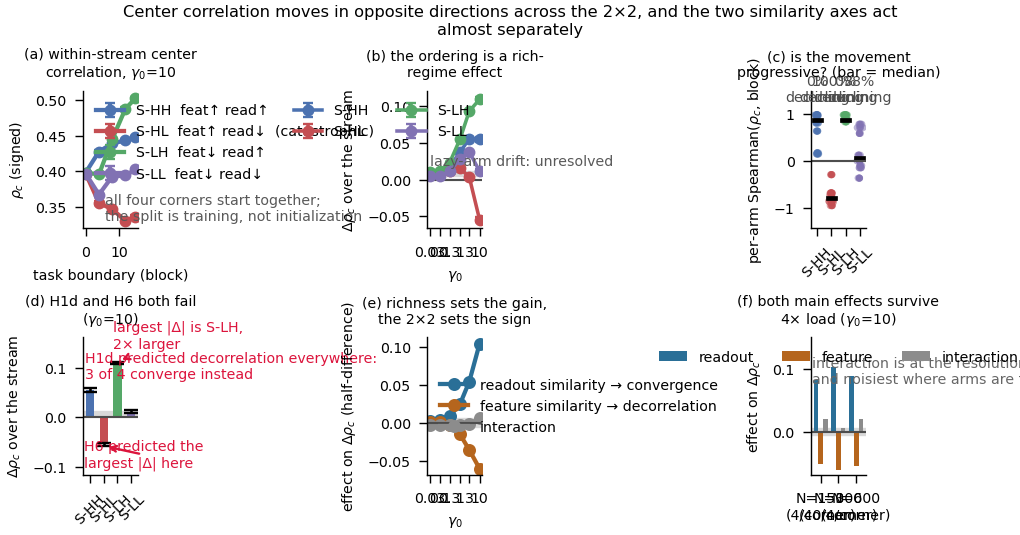

**`fig4_gamma3` — plotted values, then the rendering. Same numbers, same n, same gates.**

> **Grouping: four-corner by design — a 2×2 / per-corner split, not the forgetting pool**

**Figure S (γ = 3) — plotted values (one row per corner)**  
*n = 40; 40 arms per corner at N = 300, γ = 3; first vs last stream boundary, generic ensemble, signed ρ_c. The lazy-arm band is the Δρ_c gate.*  
*source: `figures/fig4_corners_rho_c__gamma3*.json`*

| quantity | full precision | as quoted | n | note |
|---|---|---|---|---|
| S-HH: Δρ_c | 0.0562032 | — | 40 | ±0.0020 SEM; 40 arms; 0/40 declining; sign-test p = 1.819e-12; Spearman median +0.972; lazy-band gate [0.0051, 0.0101] — outside the band |
| S-HL: Δρ_c | 0.00343988 | +0.003 | 40 | ±0.0019 SEM; 40 arms; 20/40 declining; sign-test p = 1; Spearman median -0.049; lazy-band gate [0.0051, 0.0101] — outside the band |
| S-LH: Δρ_c | 0.093601 | — | 40 | ±0.0019 SEM; 40 arms; 0/40 declining; sign-test p = 1.819e-12; Spearman median +0.985; lazy-band gate [0.0051, 0.0101] — outside the band |
| S-LL: Δρ_c | 0.0378562 | — | 40 | ±0.0014 SEM; 40 arms; 0/40 declining; sign-test p = 1.819e-12; Spearman median +0.775; lazy-band gate [0.0051, 0.0101] — outside the band |
| readout-similarity main effect | 0.0542541 | — | 80 |  |
| feature-similarity main effect | -0.0359071 | — | 80 |  |
| interaction | -0.00149077 | — | 160 |  |
| additive prediction error on S-HH | 0.00298154 | — | 160 |  |
| lazy-arm drift band (Δρ_c gate) | [0.0051, 0.0101] | [+0.005, +0.010] | — | γ = 0.03, where the representation barely moves |


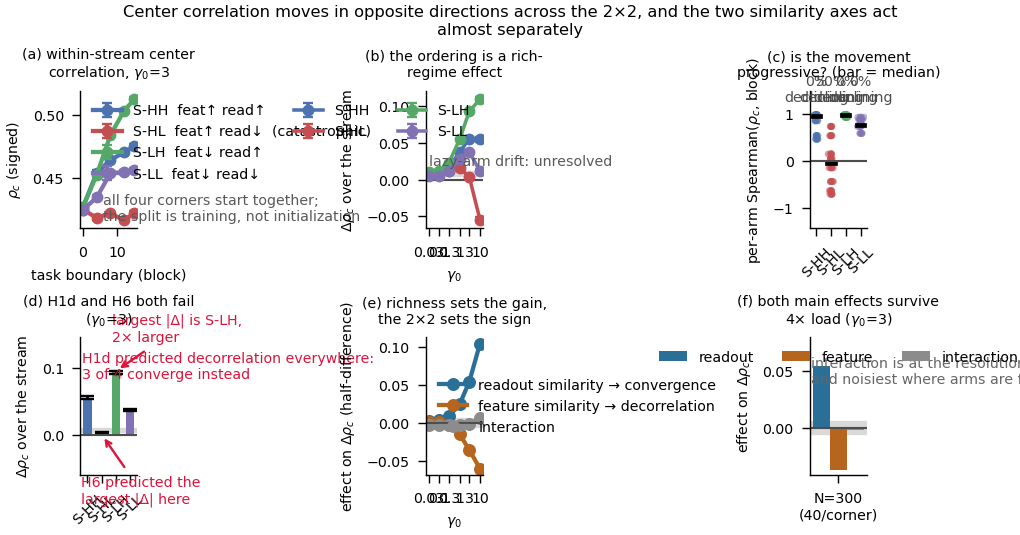

> **Grouping: four-corner by design — a 2×2 / per-corner split, not the forgetting pool**

**Center correlation across the 2×2, and the additive decomposition**  
*n = 40; 40 arms per corner at N = 300, γ = 10; first and last stream boundary*  
*source: `figures/fig4_corners_rho_c__gamma10*.json`*

| quantity | full precision | as quoted | n | note |
|---|---|---|---|---|
| S-HH: Δρ_c over the stream | 0.0551253 | — | 40 | ±0.0033 SEM; 0% of arms declining; sign-test p = 0.0000 |
| S-HL: Δρ_c over the stream | -0.0550321 | — | 40 | ±0.0033 SEM; 100% of arms declining; sign-test p = 0.0000 |
| S-LH: Δρ_c over the stream | 0.109832 | — | 40 | ±0.0029 SEM; 0% of arms declining; sign-test p = 0.0000 |
| S-LL: Δρ_c over the stream | 0.0114044 | — | 40 | ±0.0026 SEM; 38% of arms declining; sign-test p = 0.1539 |
| readout-similarity main effect | 0.104293 | +0.104 | 80 | drives convergence |
| feature-similarity main effect | -0.0605717 | −0.061 | 80 | drives decorrelation |
| interaction | 0.00586478 | +0.006 | 160 | at the resolution limit within the registered range |
| additive prediction error on the held-out corner | 0.0117296 | 0.012 | 160 |  |
| lazy-arm drift band | [0.0051, 0.0101] | [+0.005, +0.010] | — | γ = 0.03, where the representation barely moves |
| S-HL Δρ_c at γ = 3 (the limit on the claim) | 0.00343988 | +0.003 | 40 | absent at γ = 3, present at γ = 10 — the effect rests on one richness level |


> **Grouping: four-corner by design — a 2×2 / per-corner split, not the forgetting pool**

**S-HL Δρ_c onset, including the γ = 5 probe — four richnesses, with n**  
*n = 40 at γ=3,10; 16 at γ=5,30; 64 γ=5 arms on disk; generic ensemble, first vs last stream boundary; γ = 3 and 10 are the registered grid (40 arms/corner); γ = 5 is results/gamma_5/ loaded with arms_dir (64 usable arms on disk, 16 per corner); γ = 30 is results/gamma_ext/. The 16-arm and 40-arm columns are different designs.*  
*source: `results/gamma5_onset.json, results/gamma_5/*.json (arms_dir, not G.load())`*

| quantity | full precision | as quoted | n | note |
|---|---|---|---|---|
| γ = 3: S-HH Δρ_c | 0.0562032 | — | 40 | ±0.0020 SEM; n = 40 arms |
| γ = 3: S-HL Δρ_c | 0.00343988 | +0.003 | 40 | ±0.0019 SEM; n = 40 arms; 20/40 declining; sign-test p = 1 p = 1.0 |
| γ = 3: S-LH Δρ_c | 0.093601 | — | 40 | ±0.0019 SEM; n = 40 arms |
| γ = 3: S-LL Δρ_c | 0.0378562 | — | 40 | ±0.0014 SEM; n = 40 arms |
| γ = 3: additive error on S-HH | 0.00298154 | — | 160 | interaction -0.001491 |
| γ = 5: S-HH Δρ_c | 0.0649033 | — | 16 | ±0.0026 SEM; n = 16 arms |
| γ = 5: S-HL Δρ_c | -0.00639151 | −0.0064 | 16 | ±0.0021 SEM; n = 16 arms; 12/16 declining; sign-test p = 0.07681 p = 0.077 |
| γ = 5: S-LH Δρ_c | 0.105699 | — | 16 | ±0.0043 SEM; n = 16 arms |
| γ = 5: S-LL Δρ_c | 0.0389051 | — | 16 | ±0.0030 SEM; n = 16 arms |
| γ = 5: additive error on S-HH | 0.00450054 | — | 64 | interaction +0.00225 |
| γ = 10: S-HH Δρ_c | 0.0551253 | — | 40 | ±0.0033 SEM; n = 40 arms |
| γ = 10: S-HL Δρ_c | -0.0550321 | −0.055 | 40 | ±0.0033 SEM; n = 40 arms; 40/40 declining; sign-test p = 1.819e-12  |
| γ = 10: S-LH Δρ_c | 0.109832 | — | 40 | ±0.0029 SEM; n = 40 arms |
| γ = 10: S-LL Δρ_c | 0.0114044 | — | 40 | ±0.0026 SEM; n = 40 arms |
| γ = 10: additive error on S-HH | 0.0117296 | — | 160 | interaction +0.005865 |
| γ = 30: S-HH Δρ_c | 0.0461337 | — | 16 | ±0.0029 SEM; n = 16 arms |
| γ = 30: S-HL Δρ_c | -0.0955903 | — | 16 | ±0.0041 SEM; n = 16 arms; 16/16 declining; sign-test p = 3.052e-05  |
| γ = 30: S-LH Δρ_c | 0.0948738 | — | 16 | ±0.0054 SEM; n = 16 arms |
| γ = 30: S-LL Δρ_c | -0.0149221 | — | 16 | ±0.0036 SEM; n = 16 arms |
| γ = 30: additive error on S-HH | 0.0319281 | — | 64 | interaction +0.01596 |
| last non-negative γ | 3 | 3 | — |  |
| first negative γ | 5 | 5 | — | mean first negative; the sign test has not rejected |
| onset bracket factor | 1.667 | 1.67 | — | was 3.33 when the bracket was 3→10 |
| n asymmetry | 16 vs 40 | on the page | 16 vs 40 | γ = 5 is 4 streams × 4 seeds; γ = 3,10 are 5 streams × 8 seeds. Not a matched subset of the headline cell. |


> **Grouping: four-corner by design — a 2×2 / per-corner split, not the forgetting pool**

**γ = 30 extension — what saturates and what does not**  
*n = 16; 16 arms per corner at γ = 30, N = 300; fenced appendix probe, not promotable*  
*source: `results/gamma_ext/*.json`*

| quantity | full precision | as quoted | n | note |
|---|---|---|---|---|
| S-HH: Δρ_c at γ = 30 | 0.041862 | — | 16 | 95% CI [+0.0362, +0.0471] |
| S-HL: Δρ_c at γ = 30 | -0.101513 | — | 16 | 95% CI [-0.1095, -0.0930] |
| S-LH: Δρ_c at γ = 30 | 0.0897581 | — | 16 | 95% CI [+0.0789, +0.0993] |
| S-LL: Δρ_c at γ = 30 | -0.019496 | — | 16 | 95% CI [-0.0256, -0.0139] |
| interaction at γ = 30 | 0.0341211 | +0.016 | 64 | resolved here where it was not at γ ≤ 10 — additivity is range-bounded |
| readout main effect at γ = 30 | 0.126315 | — | 64 | both main effects saturate above γ = 10 while the interaction does not |


In [7]:
L.header("6. Figure 4 — the 2×2 and center correlation",
         ["figures/fig4_corners_rho_c__gamma10*.json",
          "figures/fig4_corners_rho_c__gamma3*.json",
          "results/gamma5_onset.json", "results/gamma_5/*.json",
          "results/gamma_ext/*.json"],
         note="This section uses all four corners, and that is not the pooling fault of §3: a "
              "2×2 factorial decomposition *requires* the fourth cell, and the benign corner "
              "enters as a held-out prediction rather than as an averaged-in observation. "
              "Marked **four-corner by design**. The γ = 5 probe is loaded from "
              "`results/gamma_5/` with `arms_dir` and is never adopted by `G.load()` of the "
              "registered grid. The four-row onset table states n = 16 vs n = 40 on the page; "
              "γ = 5 is not a matched 16-arm subset of the headline cell.")
L.show_figure_with_table("fig4")
L.show_figure_with_table("fig4_gamma3")
L.corners_table().display()
L.rho_c_onset_table().display()
L.corners_gamma30().display()

### 7. Width invariance, and how much precision it has

- **generating code**: `src/analysis/ledger.py` @ module hash `e6514ea6463a48a7`
- **git SHA**: `443945dc`
- **result set**: `8dd793134c38` (960 arms, a = 0 only)
- **reads**: `results/width/*.json`, `results/phase1/*.json`, `figures/fig_width_invariance__lag12__*.json`

The figure plots **four-corner n = 16** cells (4 conditions × 2 streams × 2 seeds). That companion table is marked four-corner; do not read it as the paper's 1.5% row. The paper's 1.5% / 4.5% pair is the three-corner n = 12 contrast in `width_table()`, which follows. The middle line of that table is a matched subset of the registered grid rather than all of it, so that no width difference could be a difference in sampling. The last two rows are the diagnostic that matters: the subset differs from the full grid by more than the widths differ from each other, so this table bounds a width dependence rather than measuring one.


**`fig_width` — plotted values, then the rendering. Same numbers, same n, same gates.**

> **Grouping: four-corner (what this figure plots: n = 16 = 4 conditions × 2 streams × 2 seeds). The paper's 1.5% row is the three-corner n = 12 contrast in width_table(), not these cells.**

**Figure S (width) — plotted values. FOUR-CORNER n = 16, not the paper's 1.5% row**  
*n = 16; lag 12, task 0; matched subset streams 0–1, seeds 0–1; the figure pools all four corners, so each cell is 16 comparisons. Do not read these as the paper's three-corner 1.5% / n = 12 numbers — those are width_table().*  
*source: `figures/fig_width_invariance__lag12__*.json`*

| quantity | full precision | as quoted | n | note |
|---|---|---|---|---|
| N150_g0.03 | 0.00380987 | — | 16 | +0.2056 floors; utility 0.328, radius 0.4041, dimension 0.2679 |
| N150_g1 | -0.302094 | — | 16 | +16.31 floors; utility 0.3174, radius 0.3232, dimension 0.3595 |
| N150_g10 | -0.887726 | 47.9 floors (four-corner, not quoted as forgetting) | 16 | +47.91 floors; utility 0.4718, radius 0.139, dimension 0.3892 |
| N300_g0.03 | 0.00153151 | — | 16 | +0.08266 floors; utility 0.948, radius 0.04924, dimension 0.002754 |
| N300_g1 | -0.307402 | — | 16 | +16.59 floors; utility 0.2915, radius 0.3144, dimension 0.3941 |
| N300_g10 | -0.892154 | — | 16 | +48.15 floors; utility 0.4605, radius 0.1177, dimension 0.4218 |
| N600_g0.03 | 0.00151267 | — | 16 | +0.08165 floors; utility 0.5131, radius 0.2775, dimension 0.2093 |
| N600_g1 | -0.280306 | — | 16 | +15.13 floors; utility 0.257, radius 0.2827, dimension 0.4603 |
| N600_g10 | -0.880702 | 47.5 floors (four-corner, not quoted as forgetting) | 16 | +47.54 floors; utility 0.438, radius 0.1116, dimension 0.4504 |


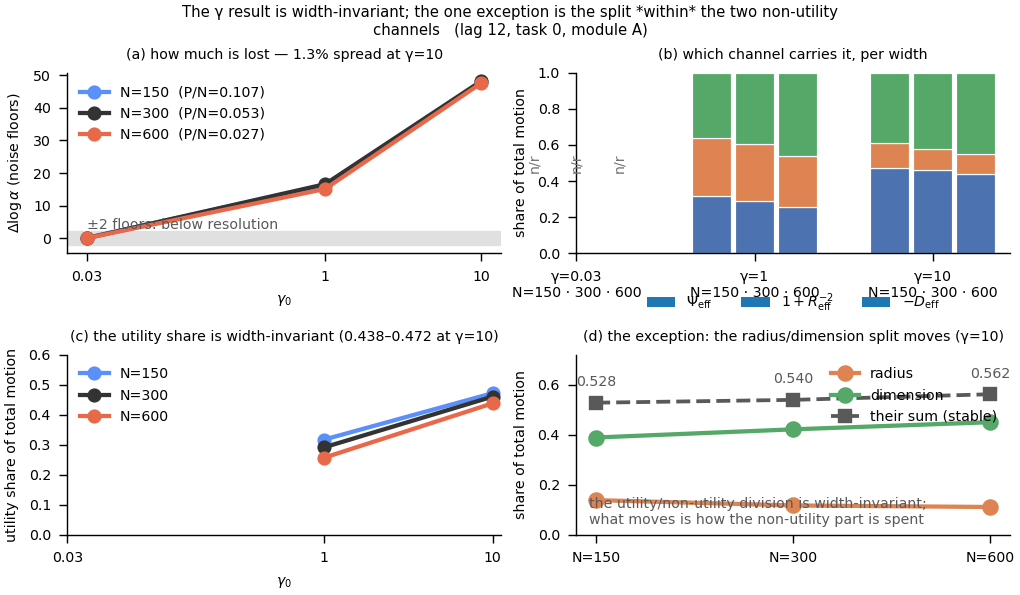

> **Grouping: three-corner (the paper's forgetting pool: S-HL, S-LH, S-LL)**

**Width invariance at matched lag and matched sampling**  
*n = 12 comparisons per cell; lag 12 (task 0), module A, three forgetting corners; N = 150 and 600 from the width arms, N = 300 from the grid's matched subset (streams 0–1, seeds 0–1)*  
*source: `results/width/*.json, results/phase1/*.json`*

| quantity | full precision | as quoted | n | note |
|---|---|---|---|---|
| N = 150: Δ log α at γ = 10 | -1.21744 | — | 12 | -65.7 floors; utility 0.468, radius 0.139, dimension 0.394 |
| N = 300 (matched, 12): Δ log α at γ = 10 | -1.23331 | — | 12 | -66.6 floors; utility 0.464, radius 0.111, dimension 0.425 |
| N = 300 (full grid, 120): Δ log α at γ = 10 | -1.29168 | — | 120 | -69.7 floors; utility 0.449, radius 0.114, dimension 0.437 |
| N = 600: Δ log α at γ = 10 | -1.21594 | — | 12 | -65.6 floors; utility 0.444, radius 0.101, dimension 0.455 |
| spread across widths at γ = 10 | 1.42162 | 1.5% | 12 per cell | the quantity usually reported as the width result |
| matched-subset vs full grid at N = 300 | 4.51855 | 4.5% | 12 vs 120 | **3.2× the spread across widths** — sampling at 12 comparisons moves the number further than width does, so the width result bounds a dependence rather than measuring one. Both are computed at the same grouping; quoting one at three corners and the other at four would make the ratio meaningless |


In [8]:
L.header("7. Width invariance, and how much precision it has",
         ["results/width/*.json", "results/phase1/*.json",
          "figures/fig_width_invariance__lag12__*.json"],
         note="The figure plots **four-corner n = 16** cells (4 conditions × 2 streams × 2 "
              "seeds). That companion table is marked four-corner; do not read it as the paper's "
              "1.5% row. The paper's 1.5% / 4.5% pair is the three-corner n = 12 contrast in "
              "`width_table()`, which follows. The middle line of that table is a matched subset "
              "of the registered grid rather than all of it, so that no width difference could "
              "be a difference in sampling. The last two rows are the diagnostic that matters: "
              "the subset differs from the full grid by more than the widths differ from each "
              "other, so this table bounds a width dependence rather than measuring one.")
L.show_figure_with_table("fig_width")
L.width_table().display()

### 8. Lag, task position, and what actually varies

- **generating code**: `src/analysis/ledger.py` @ module hash `e6514ea6463a48a7`
- **git SHA**: `443945dc`
- **result set**: `8dd793134c38` (960 arms, a = 0 only)
- **reads**: `results/phase1/*.json`, `results/audit_propagation.json`, `figures/fig2_gamma_sweep__forgetting__lag4__task0__*.json`

Lag and task position are confounded by construction: in a 16-task stream only early tasks can have long lags. Measured separately, position is the larger of the two, so any magnitude pooled by lag alone overstates lag dependence. The main decomposition avoids this by being drawn at lag 12, which exists only for task 0.

The lag-4 figure is the composition check: shares against lag 12, same three-corner grouping. The variance table's headline is the pair of zeros, not the split beneath it: stream instantiation and initialization seed explain nothing, which is what justifies pairing initializations and sharing streams. The four-corner column is kept in the notes because an earlier draft read condition as dominant, and it was the sign mixture doing that — marked, not quoted.


**`fig2_lag4` — plotted values, then the rendering. Same numbers, same n, same gates.**

> **Grouping: three-corner (the paper's forgetting pool: S-HL, S-LH, S-LL)**

**Figure S (lag 4) — plotted values, against the lag-12 shares they are compared to**  
*n = 120; lag 4, task 0, three forgetting corners*  
*source: `figures/fig2_gamma_sweep__forgetting__lag4__task0__*.json`*

| quantity | full precision | as quoted | n | note |
|---|---|---|---|---|
| γ = 0.03: Δ log α | -0.00329099 | — | 120 | -0.1776 floors; utility 0.118386, radius 0.367631, dimension 0.513982 — **below the ±2-floor band, shares not drawn**; center-collapse share n/a, coverage 0%, gate 0.0084 log units (3 × R_eff floor at this γ) |
| γ = 0.1: Δ log α | -0.0310398 | — | 120 | -1.675 floors; utility 0.0822028, radius 0.396435, dimension 0.521362 — **below the ±2-floor band, shares not drawn**; center-collapse share 0.05895350283254441, coverage 54%, gate 0.0092 log units (3 × R_eff floor at this γ) |
| γ = 0.3: Δ log α | -0.137017 | — | 120 | -7.395 floors; utility 0.185028, radius 0.370984, dimension 0.443988; center-collapse share 0.10918846848657174, coverage 62%, gate 0.0185 log units (3 × R_eff floor at this γ) |
| γ = 1: Δ log α | -0.365508 | — | 120 | -19.73 floors; utility 0.336218, radius 0.254154, dimension 0.409629; center-collapse share 0.20921415521422876, coverage 92%, gate 0.0241 log units (3 × R_eff floor at this γ) |
| γ = 3: Δ log α | -0.647514 | — | 120 | -34.95 floors; utility 0.430353, radius 0.146342, dimension 0.423305; center-collapse share 0.3083471224976039, coverage 92%, gate 0.0214 log units (3 × R_eff floor at this γ) |
| γ = 10: Δ log α | -1.01634 | — | 120 | -54.86 floors; utility 0.481652, radius 0.0949302, dimension 0.423418; center-collapse share 0.4574546091397697, coverage 88%, gate 0.0336 log units (3 × R_eff floor at this γ) |
| largest share difference vs lag 12 | 0.032466 | 0.032 | 120 | the caption's composition-holds number |
| magnitude ratio lag 12 : lag 4 at γ = 10 | 1.27091 | 1.27× | 120 |  |


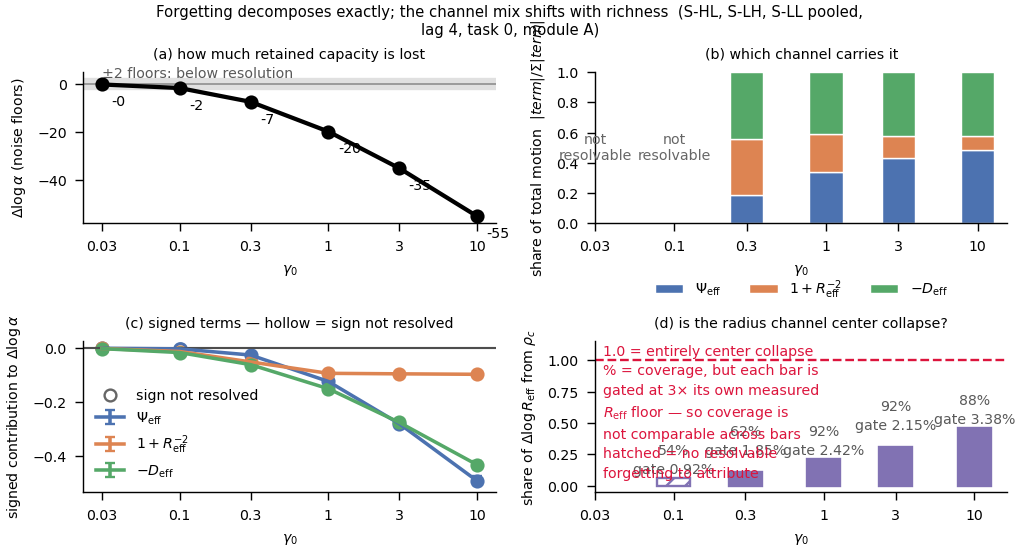

> **Grouping: three-corner (the paper's forgetting pool: S-HL, S-LH, S-LL)**

**Lag and task position, measured separately**  
*n = 360 comparisons per cell; module A, three forgetting corners, γ = 10; the lag series is within task 0, the position series at lag 4 held fixed*  
*source: `results/phase1/*.json`*

| quantity | full precision | as quoted | n | note |
|---|---|---|---|---|
| task 0, lag 4 | -1.01634 | — | 120 | -54.9 floors |
| task 0, lag 8 | -1.21486 | — | 120 | -65.6 floors |
| task 0, lag 12 | -1.29168 | — | 120 | -69.7 floors |
| task 0, lag 15 | -1.30689 | — | 120 | -70.5 floors |
| lag effect within task 0 (lag 4 → 15) | 1.28588 | 1.29× | — | ratio |
| lag 4, task 0 | -1.01634 | — | 120 | -54.9 floors |
| lag 4, task 4 | -0.764204 | — | 120 | -41.2 floors |
| lag 4, task 8 | -0.649702 | — | 120 | -35.1 floors |
| position effect at lag 4 (task 8 → 0) | 1.56431 | 1.56× | — | **larger than the lag effect** — pooling by lag alone overstates lag |


> **Grouping: three-corner (the paper's forgetting pool: S-HL, S-LH, S-LL)**

**What explains per-arm forgetting at γ = 10**  
*n = 1200; three forgetting corners, module A, all (task, lag) comparisons; OLS R², categorical predictors one-hot with the first level dropped*  
*source: `results/audit_propagation.json (scripts/audit_propagation.py)`*

| quantity | full precision | as quoted | n | note |
|---|---|---|---|---|
| stream alone | 0 | 0.000 | 1200 | four-corner value was 0.000 |
| seed alone | 0.00739217 | 0.007 | 1200 | four-corner value was 0.002 |
| distance + lag | 0.588566 | 0.589 | 1200 | four-corner value was 0.092 |
| condition alone | 0.523245 | 0.523 | 1200 | four-corner value was 0.816 |
| condition + distance + lag | 0.882148 | 0.882 | 1200 | four-corner value was 0.943 |
| + stream + seed | 0.891925 | 0.892 | 1200 | four-corner value was 0.945 |
| residual sd after all five predictors | 0.143405 | 0.143 | 1200 | against a total of 0.436; 7.7 α floors |
| implied common asymptote α_∞ | 0.525584 | 0.526 | 1200 | four-corner value was 0.815 |


In [9]:
L.header("8. Lag, task position, and what actually varies",
         ["results/phase1/*.json", "results/audit_propagation.json",
          "figures/fig2_gamma_sweep__forgetting__lag4__task0__*.json"],
         note="Lag and task position are confounded by construction: in a 16-task stream only "
              "early tasks can have long lags. Measured separately, position is the larger of "
              "the two, so any magnitude pooled by lag alone overstates lag dependence. The main "
              "decomposition avoids this by being drawn at lag 12, which exists only for task 0."
              "\n\nThe lag-4 figure is the composition check: shares against lag 12, same "
              "three-corner grouping. The variance table's headline is the pair of zeros, not "
              "the split beneath it: stream instantiation and initialization seed explain "
              "nothing, which is what justifies pairing initializations and sharing streams. "
              "The four-corner column is kept in the notes because an earlier draft read "
              "condition as dominant, and it was the sign mixture doing that — marked, not quoted.")
L.show_figure_with_table("fig2_lag4")
L.lag_task_table().display()
L.variance_table().display()


In [10]:
L.header("9. Stratification — H2d, and the pooling reversal",
         ["results/phase1/*.json"],
         note="**Four-corner pooled** (generic α vs probe, all conditions). H2d is not a forgetting magnitude, so this is not the regroup fault, but it is still four-corner and marked as such.\n\nThree levels of pooling on one question: does generic capacity predict the margin "
              "a refit readout achieves on a random dichotomy? Pooled across richness the answer "
              "is negative, within richness it is positive at γ ≥ 1, and under full "
              "stratification only γ = 10 survives. The pooled sign is a known between-γ "
              "opposition — rich training raises the capacity estimate and lowers the achieved "
              "margin — so it answers a different question than the hypothesis asks. We report "
              "the pooled statistic anyway, because a reviewer computing it would otherwise find "
              "a negative we had not addressed.")
L.stratification_table().display()


### 9. Stratification — H2d, and the pooling reversal

- **generating code**: `src/analysis/ledger.py` @ module hash `e6514ea6463a48a7`
- **git SHA**: `443945dc`
- **result set**: `8dd793134c38` (960 arms, a = 0 only)
- **reads**: `results/phase1/*.json`

**Four-corner pooled** (generic α vs probe, all conditions). H2d is not a forgetting magnitude, so this is not the regroup fault, but it is still four-corner and marked as such.

Three levels of pooling on one question: does generic capacity predict the margin a refit readout achieves on a random dichotomy? Pooled across richness the answer is negative, within richness it is positive at γ ≥ 1, and under full stratification only γ = 10 survives. The pooled sign is a known between-γ opposition — rich training raises the capacity estimate and lowers the achieved margin — so it answers a different question than the hypothesis asks. We report the pooled statistic anyway, because a reviewer computing it would otherwise find a negative we had not addressed.


> **Grouping: four-corner pooled — predates the regroup, or is the all-arm pool the paper quotes for a non-forgetting quantity; not the forgetting magnitude**

**H2d at three levels of pooling — the reversal, and where the effect lives**  
*n = 9600; all a = 0 arms, generic α against refit-readout margin, paired at the same boundary and module; Spearman, 2,000-sample bootstrap over pairs, seed 20260813*  
*source: `results/phase1/*.json`*

| quantity | full precision | as quoted | n | note |
|---|---|---|---|---|
| pooled across richness | -0.127713 | negative | 9600 | 95% CI [-0.150, -0.102] — **the reversal**: rich training raises α and lowers the margin, a between-γ opposition |
| within γ = 0.03 | 0.0555005 | — | 1600 | 95% CI [+0.005, +0.102] — excludes 0 |
| within γ = 0.1 | 0.0258142 | — | 1600 | 95% CI [-0.022, +0.069] — includes 0 |
| within γ = 0.3 | 0.00901699 | — | 1600 | 95% CI [-0.037, +0.054] — includes 0 |
| within γ = 1 | 0.107844 | — | 1600 | 95% CI [+0.059, +0.154] — excludes 0 |
| within γ = 3 | 0.189927 | — | 1600 | 95% CI [+0.141, +0.241] — excludes 0 |
| within γ = 10 | 0.321866 | — | 1600 | 95% CI [+0.270, +0.374] — excludes 0 |
| within (γ = 0.03, condition, boundary) | 0.0735294 | — | 20 cells | near zero once boundary and condition are controlled |
| within (γ = 0.1, condition, boundary) | 0.0430882 | — | 20 cells | near zero once boundary and condition are controlled |
| within (γ = 0.3, condition, boundary) | 0.00823529 | — | 20 cells | near zero once boundary and condition are controlled |
| within (γ = 1, condition, boundary) | 0.0270588 | — | 20 cells | near zero once boundary and condition are controlled |
| within (γ = 3, condition, boundary) | 0.0238235 | — | 20 cells | near zero once boundary and condition are controlled |
| within (γ = 10, condition, boundary) | 0.135441 | — | 20 cells | survives the tightest stratification |
| what the three levels say together | see note | — | 9600 | the pooled statistic is negative, the within-γ statistic is positive at γ ≥ 1, and only γ = 10 survives full stratification. The pooled sign is a between-γ opposition — rich training raises α and lowers the margin — so it answers a different question than H2d asks, and the support is concentrated in the rich regime rather than general. |


In [11]:
L.header("10. Corrections ledger",
         ["src/analysis/ledger.py::CORRECTIONS"],
         note="Every number in the paper that has been superseded, with its replacement, the "
              "reason, and where it is quoted. Four families, and they fail differently: "
              "**estimand** (the population changed, both values correct about their own), "
              "**error** (a value read from the wrong cell), **guard** (a check that returned a "
              "plausible number instead of refusing), **sign** (a transformation that destroyed "
              "the direction being measured).\n\n"
              "Read the draft against this list rather than against memory. Two of these reached "
              "drafted text *after* being corrected somewhere else, which is what a ledger is "
              "for.")
L.ledger_table().display()


### 10. Corrections ledger

- **generating code**: `src/analysis/ledger.py` @ module hash `e6514ea6463a48a7`
- **git SHA**: `443945dc`
- **result set**: `8dd793134c38` (960 arms, a = 0 only)
- **reads**: `src/analysis/ledger.py::CORRECTIONS`

Every number in the paper that has been superseded, with its replacement, the reason, and where it is quoted. Four families, and they fail differently: **estimand** (the population changed, both values correct about their own), **error** (a value read from the wrong cell), **guard** (a check that returned a plausible number instead of refusing), **sign** (a transformation that destroyed the direction being measured).

Read the draft against this list rather than against memory. Two of these reached drafted text *after* being corrected somewhere else, which is what a ledger is for.


> **Grouping: not a corner pool**

**Corrections ledger — read the draft against this**  
*n = 25; every number in the paper that has been superseded, with the reason and the family of fault; `kind` is estimand (population changed), error (wrong cell), guard (failed open), sign (transformation destroyed direction), population (two correct values compared across different populations)*  
*source: `src/analysis/ledger.py::CORRECTIONS`*

| quantity | full precision | as quoted | n | note |
|---|---|---|---|---|
| Figure 2 magnitude at γ = 10 | 50.7 floors → **69.7 floors** | — | estimand | pooled a corner that gains capacity with three that lose it; the population changed, not the computation. Status: resolved. Quoted at: 07-writeup.md §5.1, §D |
| Figure 2 magnitude at γ = 0.1 | 0.4 floors (unresolvable) → **2.1 floors (resolvable)** | — | estimand | same regroup; one further richness level clears the two-floor gate, which moved the left endpoint of every share range. Status: resolved. Quoted at: 07-writeup.md §5.1 |
| utility share range | 0.19 → 0.45 (from γ = 0.3) → **0.08 → 0.45 (from γ = 0.1)** | — | estimand | the range starts where the magnitude first clears the gate, which moved. Status: resolved. Quoted at: 07-writeup.md §5.1, §D |
| dimension share | near 0.44 throughout → **falls 0.53 → 0.44 across the first step, flat after** | — | estimand | same cause; the constancy was true only over the four-corner resolvable range. Status: resolved. Quoted at: 07-writeup.md §5.1, §D |
| width magnitudes at γ = 10 | 47.9 / 48.2 / 47.5 floors → **65.7 / 66.6 / 65.6 floors** | — | estimand | three-corner levels; the four-corner values remain correct for the like-for-like width contrast and are reported alongside. Status: resolved. Quoted at: 07-writeup.md §5.3 |
| width precision claim | varies by 1.5% → **no width dependence detectable; 1.5% bounds one** | — | estimand | the matched middle line differs from the full grid by 5.1%, three times the spread being reported. Status: resolved. Quoted at: 07-writeup.md §5.3 |
| lag effect within task 0 | 1.34× → **1.29×** | — | estimand | three-corner regroup. Status: resolved. Quoted at: 07-writeup.md §5.3, §A.1 |
| task-position effect at lag 4 | 1.7× → **1.56×** | — | estimand | three-corner regroup. Status: resolved. Quoted at: 07-writeup.md §5.3, §A.1 |
| γ = 30 magnitude at lag 12 | 71.1 floors → **94.5 floors** | — | estimand | three-corner regroup. Status: resolved. Quoted at: results/LOG.md γ = 30 probe |
| variance explained by condition alone | 0.814 → **0.523** | — | estimand | with one corner gaining, the condition variable was largely encoding the *direction* of the change rather than its size. Status: resolved. Quoted at: 07-writeup.md §5.3, §B |
| variance explained by distance + lag | 0.099 → **0.589** | — | estimand | same cause, in the other direction: no distance-above-asymptote predicts a corner moving away from the asymptote. Status: resolved. Quoted at: 07-writeup.md §5.3, §B |
| cell-mean inflation pair | 0.889 → 0.099 (factor 9) → **0.878 → 0.589 (factor 1.5)** | — | estimand | the appendix documenting the pooling fault had committed it in sizing its own example. Status: resolved. Quoted at: 07-writeup.md §A.1 |
| S-LH Δρ_c at γ = 10 | +0.0922 → **+0.1098** | — | error | read from a 4-arm width cell rather than the 40-arm grid; the row is now labelled by arm count. Status: resolved. Quoted at: 07-writeup.md §5.4, §E |
| S-LL Δρ_c at γ = 10 | +0.0246, then +0.0210 → **+0.0114** | — | error | pooled across γ, then read from the same 4-arm row; against a drift band of [+0.005, +0.010] this is 1.1× baseline. Status: **unresolved non-effect** (sign test p = 0.15). Quoted at: 07-writeup.md §5.4, §A.1 |
| panel (d) γ = 3 → 10 step | +0.004 → **−0.010** | — | guard | per-γ floor refit changed the gate at each richness. Status: **both values unresolved** (CI [−0.038, +0.070]). Quoted at: 07-writeup.md §5.1, §D |
| R_eff noise floor | one constant, CV 0.50% → **per γ, CV 0.28%–1.13%** | — | guard | measured at one setting and applied everywhere; 2.3× too permissive at the richness where the guard is used most. Status: resolved. Quoted at: 07-writeup.md §A.2 |
| panel (d) gate | 1× the floor → **3× the floor** | — | guard | a denominator at 1σ of its own noise carries ~100% relative error, so the ratio built on it is noise over noise even though the guard passed it. Status: resolved. Quoted at: 07-writeup.md §A.2 |
| ρ_c → R_eff calibration input | rho_c_glue (unnormalized) → **rho_c_signed (normalized)** | — | guard | the unnormalized convention reaches 1.49 on real representations, where the fitted form is undefined; out-of-domain inputs were clipped rather than refused. Status: resolved. Quoted at: 07-writeup.md §A.2 |
| Figure 2 panel (a) | |Δ log α| → **signed Δ log α** | — | sign | a magnitude under an axis that named a direction, so a gain of 6.2 floors was drawn at the height of a loss of 6.2. Status: resolved. Quoted at: 07-writeup.md §A.3 |
| center correlation convention | |ρ_c| → **signed ρ_c** | — | sign | H1d and H6 are claims about direction, which an absolute value cannot represent. Status: resolved. Quoted at: 07-writeup.md §A.3 |
| channel shares in the benign corner | |term| / Σ|term| → **term / net, keeping the sign** | — | sign | the magnitude share reported the radius term as contributing 11% of the gain where it subtracts 11%; a normalisation by a sum of magnitudes takes an absolute value without spelling it `abs`. Status: resolved. Quoted at: 07-writeup.md §A.3, §5.1 |
| matched-subset gap vs width spread | 5.1% against 1.5%, at different groupings → **4.5% against 1.52%, both at three corners** | — | population | each percentage was right about its own population, so the comparison between them had no defined referent; the conclusion survives but was accidentally true. Status: resolved. Quoted at: 07-writeup.md §5.3, §A.4 |
| §5.3 magnitude vs lag and position ratios | decomposition at three corners, ratios at four → **all at three corners** | — | population | adjacent sentences describing different populations, which the inventory cannot catch because both values were correct. Status: resolved. Quoted at: 07-writeup.md §5.3, §A.4 |
| peak location of the benign-corner gain | largest at γ₀ = 1 of six sampled richnesses → **no location claim; the peak moves with lag** | — | estimand | at lag 12 the peak is at γ₀ = 1.23 with a [1.18, 1.28] interval, but it slides monotonically to 2.86 at lag 4 and 0.96 at lag 15, so there is one peak per lag rather than one for the corner. Status: resolved. Quoted at: 07-writeup.md §5.1 |
| stability check on the peak across lags | range test: span 0.90 of a grid step → **monotonicity test: peak ordered by lag** | — | guard | the four peaks are 2.86, 1.75, 1.23, 0.96 — a monotone slide, which is the dependence the check existed to detect, and which a range test cannot see because it collapses an ordered sequence to its two extremes. Status: resolved. Quoted at: 07-writeup.md §A.2 |


In [12]:
L.header("11. Paper-number index — read the draft against this",
         ["paper/body.tex", "paper/figures.tex", "paper/figures-appendix.tex",
          "scripts/make_inventory.py"],
         note="Every inventoried value that appears in the paper files, in order of first "
              "appearance, with its source file, its n, and whether it clears its gate. This is "
              "what the draft is read against. Full precision beside the paper's rounding, as "
              "everywhere else.")
L.paper_index().display()


### 11. Paper-number index — read the draft against this

- **generating code**: `src/analysis/ledger.py` @ module hash `e6514ea6463a48a7`
- **git SHA**: `443945dc`
- **result set**: `8dd793134c38` (960 arms, a = 0 only)
- **reads**: `paper/body.tex`, `paper/figures.tex`, `paper/figures-appendix.tex`, `scripts/make_inventory.py`

Every inventoried value that appears in the paper files, in order of first appearance, with its source file, its n, and whether it clears its gate. This is what the draft is read against. Full precision beside the paper's rounding, as everywhere else.


> **Grouping: mixed; per-row n is the claim's own**

**Paper-number index — every inventoried value in the paper, in appearance order**  
*n = 40; values whose quote or distinctive rendering occurs in paper/body.tex, paper/figures.tex, or paper/figures-appendix.tex; n as inventoried*  
*source: `scripts/make_inventory.py::rows() against the three paper files`*

| quantity | full precision | as quoted | n | note |
|---|---|---|---|---|
| §5.1 forgetting at γ₀=10 | 69.7175 | 69.7 | 120 | source `figures/fig2_gamma_sweep__forgetting__lag12__960arms__8dd793134c38.json`; appears paper/body.tex; see unresolved_claims_table() if the paper flags it; else quoted |
| §5.1 forgetting at γ₀=0.03 (nothing happens) | 0.175613 | 0.2 | — | source `figures/fig2_gamma_sweep__forgetting__lag12__960arms__8dd793134c38.json`; appears paper/body.tex; see unresolved_claims_table() if the paper flags it; else quoted |
| §5.1 S-HH radius term at γ₀=3 in R_eff floors | 0.21505 | 0.2 | 40 | source `figures/fig2_gamma_sweep__S-HH__lag12__960arms__8dd793134c38.json`; appears paper/body.tex; see unresolved_claims_table() if the paper flags it; else quoted |
| §5.1 utility share at γ₀=0.1 (first resolvable) | 0.0833736 | 0.083 | — | source `figures/fig2_gamma_sweep__forgetting__lag12__960arms__8dd793134c38.json`; appears paper/body.tex:95; see unresolved_claims_table() if the paper flags it; else quoted |
| §5.1 center-collapse share at γ₀=10 | 0.44955 | 0.45 | — | source `figures/fig2_gamma_sweep__forgetting__lag12__960arms__8dd793134c38.json`; appears paper/body.tex; unresolved (γ=3→10 step CI includes 0) |
| §5.3 dimension share at γ₀=10, N=600 | 0.450373 | 0.45 | — | source `figures/fig_width_invariance__lag12__2f8b522a6423.json`; appears paper/body.tex; see unresolved_claims_table() if the paper flags it; else quoted |
| §5.1 dimension share at γ₀=0.1 | 0.529697 | 0.53 | — | source `figures/fig2_gamma_sweep__forgetting__lag12__960arms__8dd793134c38.json`; appears paper/body.tex; see unresolved_claims_table() if the paper flags it; else quoted |
| §5.1 S-HH capacity change at γ₀=1 (largest on the grid) | 11.8423 | 11.8 | 40 | source `figures/fig2_gamma_sweep__S-HH__lag12__960arms__8dd793134c38.json`; appears paper/body.tex; resolved |
| §5.1 S-HH capacity change at γ₀=10 | 6.15994 | 6.2 | 40 | source `figures/fig2_gamma_sweep__S-HH__lag12__960arms__8dd793134c38.json`; appears paper/body.tex; resolved |
| §5.1 cells examined for a capacity gain | 520 | 520 | — | source `results/audit_propagation.json`; appears paper/body.tex; see unresolved_claims_table() if the paper flags it; else quoted |
| §5.1 S-HH (task, lag) cells resolving as gains at γ₀=10 | 10 | 10 | 400 | source `results/tier2_backward_transfer.json`; appears paper/body.tex:121; see unresolved_claims_table() if the paper flags it; else quoted |
| §5.1 S-HH gain at matched lag 4, task 0, γ₀=10 | 8.74931 | 8.7 | 40 | source `results/tier2_backward_transfer.json`; appears paper/body.tex:124; see unresolved_claims_table() if the paper flags it; else quoted |
| §5.1 S-HH gain at matched lag 4, task 8, γ₀=10 | 12.7541 | 12.8 | 40 | source `results/tier2_backward_transfer.json`; appears paper/body.tex; see unresolved_claims_table() if the paper flags it; else quoted |
| §5.1 S-HH gain within task 0 at lag 15, γ₀=10 | 3.12557 | 3.1 | 40 | source `results/tier2_backward_transfer.json`; appears paper/body.tex:125; see unresolved_claims_table() if the paper flags it; else quoted |
| §5.4 S-LL sign-test p at γ₀=10 | 0.15386 | 0.15 | — | source `figures/fig4_corners_rho_c__gamma10__960arms__8dd793134c38.json`; appears paper/body.tex; unresolved (sign-test p = 0.15; inside/at the lazy band) |
| §5.1 S-HH radius term at γ₀=1 in R_eff floors | 1.91739 | 1.9 | 40 | source `figures/fig2_gamma_sweep__S-HH__lag12__960arms__8dd793134c38.json`; appears paper/body.tex:133; see unresolved_claims_table() if the paper flags it; else quoted |
| §5.1 S-HH radius term at γ₀=10 in R_eff floors | 1.10529 | 1.1 | 40 | source `figures/fig2_gamma_sweep__S-HH__lag12__960arms__8dd793134c38.json`; appears paper/body.tex; see unresolved_claims_table() if the paper flags it; else quoted |
| §5.1 S-HH signed utility share of the net gain at γ₀=10 | 0.48448 | 0.484 | 40 | source `results/tier2_backward_transfer.json`; appears paper/body.tex:138; see unresolved_claims_table() if the paper flags it; else quoted |
| §5.1 interpolated peak of the S-HH gain at lag 12 | 1.22712 | 1.23 | 40 | source `results/tier2_backward_transfer.json`; appears paper/body.tex:147; see unresolved_claims_table() if the paper flags it; else quoted |
| §5.1 peak of the S-HH gain at lag 4 | 2.85686 | 2.86 | 40 | source `results/tier2_backward_transfer.json`; appears paper/body.tex:149; see unresolved_claims_table() if the paper flags it; else quoted |
| §5.1 peak of the S-HH gain at lag 15 | 0.962098 | 0.96 | 40 | source `results/tier2_backward_transfer.json`; appears paper/body.tex; see unresolved_claims_table() if the paper flags it; else quoted |
| §5.1 center-collapse share at γ₀=0.1 | 0.0534677 | 0.053 | — | source `figures/fig2_gamma_sweep__forgetting__lag12__960arms__8dd793134c38.json`; appears paper/body.tex; see unresolved_claims_table() if the paper flags it; else quoted |
| §5.4 S-HL Δρ_c at γ₀=10 (the decorrelating corner) | -0.0550321 | -0.055 | — | source `figures/fig4_corners_rho_c__gamma10__960arms__8dd793134c38.json`; appears paper/body.tex; see unresolved_claims_table() if the paper flags it; else quoted |
| §5.4 S-HL median Spearman(ρ_c, block) at γ₀=10 | -0.787786 | -0.79 | — | source `figures/fig4_corners_rho_c__gamma10__960arms__8dd793134c38.json`; appears paper/body.tex; see unresolved_claims_table() if the paper flags it; else quoted |
| §5.4 S-HL Δρ_c at γ₀=5 | -0.00639151 | -0.0064 | 16 | source `results/gamma5_onset.json`; appears paper/body.tex:203; unresolved (sign-test p = 0.077 has not rejected) |
| §5.4 S-HL arms declining at γ₀=5 | 12 | 12 | 16 | source `results/gamma5_onset.json`; appears paper/body.tex:204; unresolved (sign-test p = 0.077 has not rejected) |
| §5.4 S-HL sign-test p at γ₀=5 | 0.0768127 | 0.077 | 16 | source `results/gamma5_onset.json`; appears paper/body.tex:204; unresolved (sign-test p = 0.077 has not rejected) |
| §5.4 onset bracket factor 3→5 | 1.667 | 1.67 | — | source `results/gamma5_onset.json`; appears paper/body.tex:205; see unresolved_claims_table() if the paper flags it; else quoted |
| §5.3 utility-share spread across widths at γ₀=10 (three-corner) | 0.0240821 | 0.024 | — | source `results/audit_propagation.json`; appears paper/body.tex; see unresolved_claims_table() if the paper flags it; else quoted |
| §5.3 matched-subset vs full-grid gap at N=300, γ₀=10 | 4.51855 | 4.5 | 12 vs 120 | source `results/audit_propagation.json`; appears paper/body.tex:213; bound, not a measurement (sampling gap 4.5% > width spread 1.5%) |
| §5.3 radius share at γ₀=10, N=150 | 0.139036 | 0.139 | — | source `figures/fig_width_invariance__lag12__2f8b522a6423.json`; appears paper/body.tex; see unresolved_claims_table() if the paper flags it; else quoted |
| §5.3 lag effect within task 0 at γ₀=10 (lag 4 → 15) | 1.28588 | 1.29 | 360 | source `results/audit_propagation.json`; appears paper/body.tex; see unresolved_claims_table() if the paper flags it; else quoted |
| §5.3 task-position effect at fixed lag 4, γ₀=10 (task 8 → 0) | 1.56431 | 1.56 | 360 | source `results/audit_propagation.json`; appears paper/body.tex; see unresolved_claims_table() if the paper flags it; else quoted |
| §5.3 largest share difference, lag 12 vs lag 4 (task 0) | 0.032466 | 0.032 | — | source `figures/fig2_gamma_sweep__forgetting__lag4__task0__960arms__8dd793134c38.json`; appears paper/body.tex:223; see unresolved_claims_table() if the paper flags it; else quoted |
| §B variance explained by initialization seed alone | 0.00739217 | 0.007 | 1200 | source `results/audit_propagation.json`; appears paper/body.tex; see unresolved_claims_table() if the paper flags it; else quoted |
| §B variance explained by distance above the asymptote + lag | 0.588566 | 0.589 | 1200 | source `results/audit_propagation.json`; appears paper/body.tex; see unresolved_claims_table() if the paper flags it; else quoted |
| §B variance explained by stream condition alone | 0.523245 | 0.523 | 1200 | source `results/audit_propagation.json`; appears paper/body.tex; see unresolved_claims_table() if the paper flags it; else quoted |
| §B variance explained by condition + distance + lag | 0.882148 | 0.882 | 1200 | source `results/audit_propagation.json`; appears paper/body.tex; see unresolved_claims_table() if the paper flags it; else quoted |
| §5.1 arms behind each richness level | 120 | 120 | — | source `figures/fig2_gamma_sweep__forgetting__lag12__960arms__8dd793134c38.json`; appears paper/figures.tex; see unresolved_claims_table() if the paper flags it; else quoted |
| §5.3 magnitude ratio, lag 12 : lag 4 within task 0, at γ₀=10 | 1.27091 | 1.27 | — | source `figures/fig2_gamma_sweep__forgetting__lag4__task0__960arms__8dd793134c38.json`; appears paper/figures-appendix.tex; see unresolved_claims_table() if the paper flags it; else quoted |


In [13]:
L.header("12. Unresolved claims — the number that makes each one so",
         ["figures/*.json", "results/gamma5_onset.json",
          "results/gamma5_n40_onset.json", "results/audit_propagation.json",
          "results/unique_n8.json", "results/LOG.md"],
         note="Every quantity the paper mentions that does not clear its gate, with the gate "
              "and the margin. Sign tests and SEMs on the registered grid are at unique n=8. "
              "S-LL is unique p=0.73 — nothing, not the old marginal-sounding p=0.15. "
              "γ=5 S-HL at genuine n=40 is resolved (p=6.8e-4); the duplicate-stream 3/4 "
              "result stays in unique_n_status_table() as the before. The duplication itself "
              "is the first row: a filename field stored and never read.")
L.unresolved_claims_table().display()
L.unique_n_status_table().display()


### 12. Unresolved claims — the number that makes each one so

- **generating code**: `src/analysis/ledger.py` @ module hash `e6514ea6463a48a7`
- **git SHA**: `443945dc`
- **result set**: `8dd793134c38` (960 arms, a = 0 only)
- **reads**: `figures/*.json`, `results/gamma5_onset.json`, `results/audit_propagation.json`, `results/LOG.md`

Every quantity the paper mentions that does not clear its gate, with the gate and the margin: the S-HH radius series, the γ=3→10 centre-collapse step, the γ=5 sign test, the width 1.5% bound, S-LL Δρ_c, the Figure 4 interaction, panel (d) coverage at γ=0.03, and the γ=0.1 forgetting onset. If the paper says something is unresolved, the number that makes it so is here.


**Unresolved claims — the number that makes each one so**  
*n = see per-row n; every quantity the paper mentions whose gate has not been cleared, including bounds the paper states as bounds*  
*source: `figure sidecars, results/gamma5_onset.json, results/audit_propagation.json, results/LOG.md (panel (d) CI)`*

| quantity | full precision | as quoted | n | note |
|---|---|---|---|---|
| S-HH radius term at γ = 0.03 | 0.00589757 | — | 40 | gate 0.0084 log units (3σ R_eff); 2.11 R_eff floors; margin -0.0025 (negative = short of the gate). Paper: no sign, only a bound under 2 floors. |
| S-HH radius term at γ = 1 | -0.0154302 | 1.9 floors | 40 | gate 0.0241 log units (3σ R_eff); 1.92 R_eff floors; margin -0.0087 (negative = short of the gate). Paper: no sign, only a bound under 2 floors. |
| S-HH radius term at γ = 3 | -0.00153214 | 0.2 floors | 40 | gate 0.0214 log units (3σ R_eff); 0.22 R_eff floors; margin -0.0198 (negative = short of the gate). Paper: no sign, only a bound under 2 floors. |
| S-HH radius term at γ = 10 | -0.012365 | 1.1 floors | 40 | gate 0.0336 log units (3σ R_eff); 1.11 R_eff floors; margin -0.0212 (negative = short of the gate). Paper: no sign, only a bound under 2 floors. |
| γ = 3 → 10 center-collapse step (difference of sidecar medians) | 0.00786446 | −0.010 (LOG.md refit); CI [−0.038, +0.070] | 120 | gate: CI must exclude 0. The quoted CI includes 0 (margin: 0 is 0.038 from the lower end, 0.070 from the upper). Sidecar difference of medians is shown at full precision; the paper quotes the per-arm-refit step from results/LOG.md, which is the same unresolved verdict. |
| panel (d) coverage at γ = 0.03 | 0 | 0% | 120 | gate 0.0084 log units; nothing clears, so the bar is empty rather than a measured share |
| γ = 5 S-HL sign test | 0.0768127 | p = 0.077 | 16 | gate: two-sided sign test at 0.05. Observed 12/16 declining; p = 0.07681; Δρ_c = -0.006392 ± 0.002058. The mean is negative; the test has not rejected. n = 16, not 40. |
| γ = 3 S-HL (the other end of the onset bracket) | 0.00343988 | +0.003, p = 1.0 | 40 | sign test p = 1.0; 20/40 declining. Absent, not a weak version of γ = 10. |
| S-LL Δρ_c at γ = 10 | 0.0114044 | +0.0114, p = 0.15 | 40 | gate: sign test 0.05 and the lazy-arm band [0.0051, 0.0101]. p = 0.1539; 15/40 declining; 1.1× the top of the band. Coin-flip, not a corner effect. |
| Figure 4 interaction at γ = 10 | 0.00586478 | +0.006 | 160 | paper: at the resolution limit within the registered range. Not a detected non-additivity; the additive model still predicts S-HH to 0.012. |
| width spread at γ = 10 (three-corner) | 1.42162 | 1.5% | 12 per cell | gate: distinguishable from sampling. Sampling gap is 4.52% (3.2× the spread). 1.5% is a bound, not a measured invariance. |
| matched-subset vs full-grid gap at N = 300, γ = 10 | 4.51855 | 4.5% | 12 vs 120 | the number that makes the 1.5% a bound |
| forgetting at γ = 0.1 (first resolvable) | 2.10197 | 2.1 floors | 120 | gate: ±2 α floors. Observed 2.102; margin +0.10 floors. Fragile: a 20% floor error would put it back under the gate. |


In [ ]:
L.header("13. Result-set populations — the draft is checked against this",
         ["results/phase1/", "results/gamma_5/", "results/gamma_5_n40/",
          "results/width/", "results/width_g10_n40/", "results/gamma_ext/",
          "results/unconfound_k3/", "results/unconfound_k3_precommit.json",
          "results/unique_n8.json"],
         note="Four (soon six) populations. A sentence that compares a genuine-n number "
              "to a unique-n=8 number without saying so is the §A.4 mismatched-population "
              "fault. This table is what the draft is checked against for population "
              "consistency, the way §12 is checked for resolution. K=3's reading was "
              "written to results/unconfound_k3_precommit.json before any of those arms "
              "existed: reproduce across three arrangements ⇒ not arrangement-specific; "
              "fail ⇒ the paper's scope narrows. K=3 cannot estimate arrangement-level "
              "variance. It is not pooled with the grid.")
L.population_table().display()

In [14]:
L.header("14. Caption cuts — proposed, not applied",
         ["paper/figures.tex", "paper/figures-appendix.tex"],
         note="The proposed halves are landed in `paper/figures.tex` and "
              "`paper/figures-appendix.tex`. The list below is what each cut sentence was doing "
              "(number, scope, or interpretation). Restore any sentence the figure cannot carry "
              "alone; the page count in the last compile is with these captions.")
L.caption_cut_proposal()
         ["paper/figures.tex", "paper/figures-appendix.tex"],
         note="The proposed halves are landed in `paper/figures.tex` and "
              "`paper/figures-appendix.tex`. The list below is what each cut sentence was doing "
              "(number, scope, or interpretation). Restore any sentence the figure cannot carry "
              "alone; the page count in the last compile is with these captions.")
L.caption_cut_proposal()


### 13. Caption cuts — proposed, not applied

- **generating code**: `src/analysis/ledger.py` @ module hash `e6514ea6463a48a7`
- **git SHA**: `443945dc`
- **result set**: `8dd793134c38` (960 arms, a = 0 only)
- **reads**: `paper/figures.tex`, `paper/figures-appendix.tex`

The proposed halves are landed in `paper/figures.tex` and `paper/figures-appendix.tex`. The list below is what each cut sentence was doing (number, scope, or interpretation). Restore any sentence the figure cannot carry alone; the page count in the last compile is with these captions.


## Caption cuts — proposed, not applied

Each current caption, a version at roughly half the word count, and what every cut sentence was doing (number, scope, or interpretation). The proposed halves are what landed in `paper/figures.tex` and `paper/figures-appendix.tex`. Restore any sentence the figure cannot carry alone.

### fig:decomposition (Figure 2)

- current: **328 words**
- proposed: **146 words** (45% of current)

**Proposed caption**

Forgetting decomposes exactly, and the channel that carries it shifts with richness. Retained capacity for task 0 at lag 12, decomposed by the exact identity of Chou 2026. Pooled over the three conditions that lose capacity (120 arms per γ); S-HH is Figure fig:benign. (a) Magnitude in noise floors, signed: 0.2 at γ0=0.03 to 69.7 at γ0=10. Grey band: ±2 floors. (b) Channel shares, |term|/Σ|term|, drawn where the total clears the band (γ0=0.1 and above): utility 0.08→0.45, radius 0.39→0.11, dimension 0.53→0.44 then flat. (c) Signed terms; utility negative on 100% of arms for γ0≥1. (d) Center-collapse share of the radius channel, 0.05→0.44 through γ0=3 then flat (γ0=3→10 step unresolved, CI [−0.038,+0.070]). Each bar gated at 3× its own R_eff floor; coverage is not comparable across bars. Lag 12 exists only for task 0, the most-forgotten task — the largest forgetting in the grid, not its average.

**What each cut (or compressed) sentence was doing**

- *scope — names the estimand, the lag, and the identity.* Retained capacity α(·; y_j) for task 0, measured at its own task boundary and again twelve boundaries later, decomposed by the exact identity … of Chou 2026.
- *scope — grouping and n; pointer to the other figure.* Pooled over the three stream conditions that lose capacity (… 120 arms per richness level); the benign corner S-HH … is shown separately in Figure fig:benign.
- *number — kept, compressed.* (a) Magnitude in units of the estimator's measured Monte-Carlo noise floor, signed: 0.2 floors at γ0=0.03, rising to 69.7 at γ0=10.
- *scope — the resolution gate drawn on the panel.* The grey band marks ±2 floors, below which nothing is resolvable.
- *number — kept, compressed; the |term|/Σ|term| definition is the cut.* (b) Channel composition, |term|/Σ|term|, drawn only where the total clears the band — γ0=0.1 and above; the utility channel grows from 0.08 to 0.45 … dimension … flat thereafter.
- *number + scope — hollow-marker convention cut; 100% kept.* (c) The same terms with their signs, hollow markers where a term's sign is not resolved across arms; the utility term is negative on 100% of arms for γ0 ≥ 1.
- *scope — names the calibration; cut if the panel axis already says it.* (d) How much of the radius channel is center collapse: the change in ρ_c converted through a synthetic-manifold calibration, as a fraction of the observed radius change.
- *number — kept.* Rising from 0.05 to 0.44 through γ0=3 and then flat — the γ0=3→10 step is not resolved (bootstrap CI [−0.038,+0.070]).
- *scope — the incomparable-coverage warning; kept compressed.* Each bar is gated at three times the R_eff noise floor measured at its own richness, printed on the bar with its coverage; because the threshold differs per bar the coverage percentages are not comparable across bars.
- *scope — lag/task confound; interpretation — 'largest not average'. Boundaries list cut; the rest compressed.* Lag 12 exists only for task 0 in a 16-task stream with boundaries at 0, 4, 8, 12, 15, so this is a task-0 figure by construction, and task 0 is the most-forgotten task — it reports the largest forgetting in the grid rather than its average.

### fig:corners (Figure 4)

- current: **265 words**
- proposed: **101 words** (38% of current)

**Proposed caption**

Center correlation moves in opposite directions across the 2×2, and the two axes act almost separately. (a) Signed ρ_c at γ0=10, Hiratani 2024 design. All four corners start together (ρ_c = 0.391–0.392); three converge, S-HL (same stimuli, different rules) decorrelates. (b) Grey band: lazy-arm drift (γ0=0.03). S-LL never leaves it. (c) S-HL decline is progressive, negative on 40/40 arms, median Spearman −0.79. (d) H1d and H6 fail in sign: three of four corners converge; largest |Δρ_c| is S-LH, twice S-HL. (e) Readout +0.104, feature −0.061, interaction +0.006; additive error 0.012. (f) Both main effects survive a 4× width change, ordering unchanged.

**What each cut (or compressed) sentence was doing**

- *scope — citation and design name; cut if the body already carries it.* (a) … per corner of the feature × readout similarity design of Hiratani 2024
- *number + interpretation — numbers kept; 'training not init' compressed into 'start together'.* all four corners begin together (ρ_c = 0.391–0.392), so the split is produced by training rather than by initialization.
- *scope — the parenthetical gloss of S-HL; cut. Direction kept..* Three corners converge; S-HL — high feature similarity, low readout similarity, the same stimuli under different rules — decorrelates.
- *scope + interpretation — 'rich-regime effect' cut; band and S-LL kept.* (b) The same endpoint difference across the richness sweep, with the grey band showing the drift measured in lazy arms (γ0=0.03), where the representation barely moves; the corner ordering is a rich-regime effect, and S-LL never leaves the band.
- *interpretation — correspondence with the human result; cut from the caption.* (c) … which is the form the practice result of Menghi 2025 takes.
- *interpretation + number — kept compressed.* (d) Both pre-registered predictions fail. H1d … H6 … twice the size.
- *interpretation — the gain/sign slogan; cut from the caption (body already has it).* (e) … across the registered range both effects grow with richness at a roughly constant ratio, so richness sets the gain and the design sets the sign.
- *number/scope — kept compressed.* (f) Both main effects survive a 4× change in width, with the corner ordering identical at all three widths.

### fig:benign

- current: **85 words**
- proposed: **44 words** (52% of current)

**Proposed caption**

The benign corner gains retained capacity. S-HH alone, 40 arms per γ, same decomposition as Figure fig:decomposition. Largest at γ0=1 (11.8 floors), 6.2 by γ0=10. Radius term not resolved at γ0≥1 (1.9, 0.2, 1.1 floors) — a bound under 2 floors, not a sign.

**What each cut (or compressed) sentence was doing**

- *scope — kept compressed.* The same decomposition as Figure fig:decomposition, for S-HH alone (40 arms per richness level).
- *number — kept.* Δ log α is positive at every richness, largest at γ0=1 with 11.8 floors and falling to 6.2 by γ0=10.
- *interpretation — cut; the bound on radius is the claim this panel has to carry.* Utility and dimension move in the gaining direction.
- *number + scope — floors kept; the 11.7–14.1 comparison is in the body and can leave the caption.* The radius term is not resolved at any γ0≥1 (1.9, 0.2 and 1.1 floors), so this panel claims no sign for it — only a bound, under 2 floors against 11.7 to 14.1 in the forgetting corners.

### fig:lag4

- current: **56 words**
- proposed: **26 words** (46% of current)

**Proposed caption**

The composition holds at a shorter lag. Figure fig:decomposition at lag 4, task 0. Shares agree with lag 12 to within 0.032; magnitude changes by 1.27×.

**What each cut (or compressed) sentence was doing**

- *scope — kept compressed.* Figure fig:decomposition redrawn at lag 4 within task 0.
- *number — kept.* The channel shares agree with lag 12 to within 0.032 at every richness while the magnitude changes by 1.27×
- *interpretation — cut; the two numbers already say it.* so the composition is a property of the richness rather than of the particular cell the main figure is drawn at.

### fig:width

- current: **89 words**
- proposed: **40 words** (45% of current)

**Proposed caption**

Width robustness, in the main figure's form. N ∈ {150,300,600}, matched subset (streams 0–1, seeds 0–1; 144 arms). At γ0=10 magnitude varies by 1.5%, utility share by 0.024. A bound: the matched subset differs from the full grid by 4.5%.

**What each cut (or compressed) sentence was doing**

- *scope — kept.* The decomposition at N ∈ {150, 300, 600} on a matched subset (streams 0–1, seeds 0–1; 144 arms).
- *number + interpretation — 'no dependence' is the interpretation; 1.5% and 0.024 kept. Note 1.5% is three-corner n=12; the figure cells are four-corner n=16..* No width dependence is detectable: forgetting magnitude at γ0=10 varies by 1.5% across a 4× change in width, and the utility share by 0.024.
- *number + interpretation — 4.5% kept; 'three times' and 'edge of what this contrast can resolve' compressed to 'a bound'.* That figure bounds an effect rather than measuring one — the matched subset differs from the full grid by 4.5% at γ0=10, three times the spread across widths, so 1.5% is at the edge of what this contrast can resolve.

### fig:corners-gamma3

- current: **64 words**
- proposed: **32 words** (50% of current)

**Proposed caption**

The corner structure at γ0=3. S-HL decorrelation absent (+0.003, p=1.0). At γ0=5 the mean is first negative (−0.0064±0.0021, 12/16 arms, p=0.077, n=16); at γ0=10, 40/40. Onset between 3 and 5 (bracket 1.67).

**What each cut (or compressed) sentence was doing**

- *number + scope — kept compressed.* Figure fig:corners redrawn one richness step lower, where the S-HL decorrelation has not yet appeared (+0.003, p = 1.0).
- *number — kept; n=16 made explicit in the proposal so the asymmetry is in the caption.* A probe at γ0=5 finds the mean first negative (−0.0064±0.0021, declining on 12 of 16 arms, sign-test p=0.077); at γ0=10 it is unanimous on 40 of 40.
- *number — 1.67 kept; 'it was 3.33' is history of a previous bracket, cut.* The onset sits between 3 and 5 (bracket factor 1.67; it was 3.33).


In [15]:
L.show(f"Ran top to bottom in **{time.time() - T0:.1f} s** against result set "
       f"`{L.result_set_sha()}`, git `{L.git_sha()}`. "
       f"{len(L.CORRECTIONS)} entries in the corrections ledger. "
       "Nothing in this notebook trained or measured anything.")

Ran top to bottom in **5.3 s** against result set `8dd793134c38`, git `443945dc`. 25 entries in the corrections ledger. Nothing in this notebook trained or measured anything.